Code to replicate cross-border climate risk analysis, with ICIO as MRIOT and INFORM Climate Change as climate risk index.

# MRIOT
----

## ICIO

In [2]:
import pymrio
oecd_storage = "MRIOT/ICIO/ICIO2021_2018.zip"
oecd_file = pymrio.parse_oecd(path=oecd_storage)

oecd_file.rename_sectors(    {"01T02":	"Agriculture, hunting, forestry",
"03":	"Fishing and aquaculture",
"05T06":	"Mining and quarrying, energy producing products",
"07T08":	"Mining and quarrying, non-energy producing products",
"09":	"Mining support service activities",
"10T12":	"Food products, beverages and tobacco",
"13T15":	"Textiles, textile products, leather and footwear",
"16":	"Wood and products of wood and cork",
"17T18":	"Paper products and printing",
"19":	"Coke and refined petroleum products",
"20":	"Chemical and chemical products",
"21":	"Pharmaceuticals, medicinal chemical and botanical products",
"22":	"Rubber and plastics products",
"23":	"Other non-metallic mineral products",
"24":	"Basic metals",
"25":	"Fabricated metal products",
"26":	"Computer, electronic and optical equipment",
"27":	"Electrical equipment",
"28":	"Machinery and equipment, nec ",
"29":	"Motor vehicles, trailers and semi-trailers",
"30":	"Other transport equipment",
"31T33":	"Manufacturing nec; repair and installation of machinery and equipment",
"35":	"Electricity, gas, steam and air conditioning supply",
"36T39":	"Water supply; sewerage, waste management and remediation activities",
"41T43":	"Construction",
"45T47":	"Wholesale and retail trade; repair of motor vehicles",
"49":	"Land transport and transport via pipelines",
"50":	"Water transport",
"51":	"Air transport",
"52":	"Warehousing and support activities for transportation",
"53":	"Postal and courier activities",
"55T56":	"Accommodation and food service activities",
"58T60":	"Publishing, audiovisual and broadcasting activities",
"61":	"Telecommunications",
"62T63":	"IT and other information services",
"64T66":	"Financial and insurance activities",
"68":	"Real estate activities",
"69T75":	"Professional, scientific and technical activities",
"77T82":	"Administrative and support services",
"84":	"Public administration and defence; compulsory social security",
"85":	"Education",
"86T88":	"Human health and social work activities",
"90T93":	"Arts, entertainment and recreation",
"94T96":	"Other service activities",
"97T98":	"Activities of households as employers; undifferentiated goods- and services-producing activities of households for own use"
})

oecd_file.calc_all()
mriot = oecd_file

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1671: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  Z.loc[co_name, :] + Z.loc[agg_list, :].groupby(level="sector", axis=0).sum()
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1675: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  Y.loc[co_name, :] + Y.loc[agg_list, :].groupby(level="sector", axis=0).sum()
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1681: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  Z.loc[:, co_name] + Z.loc[:, agg_list].groupby(level="sector", axis=1).sum()
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\pymrio\tools\ioparser.py:1687: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` witho

# Climate risk index
----

## INFORM Climate Change Risk
---

Here INFORM Climate Change is imported. There are 191 countries in INFORM CC and 67 in ICIO (ROW is 67th).

Among 66 countries of ICIO, 2 are not in INFORM CC : Taiwan and Honk Kong. We give them China's risk index and modify Climate_Risk_INFORMCC to this effect, so that it has 193 countries in the end.

In [3]:
import pandas as pd
import numpy as np

file_path = 'INFORM_Climate_Change/INFORM_Climate_Change_Index/InformCC_usable.xlsx'
Climate_Risk_INFORMCC = pd.read_excel(file_path)

# Namibia is interpreted as "NaN". This is correct below
Climate_Risk_INFORMCC['Country'].fillna("NA", inplace=True)

# Calculate the "Change in Risk' column
Climate_Risk_INFORMCC['Change in Risk'] = Climate_Risk_INFORMCC['INDEX 2050 Pessimistic']-Climate_Risk_INFORMCC['INFORM 2022']
      
## Distributing EORA's countries by risk level
#########

# Importing EORA's countries (3-letter code)

L= mriot.L
country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()
MRIOT_3_letters = list(country_list).copy()

# Conversion table (2-letter code / 3-letter)

csv_file = "Other_data/country_codes.csv"
iso_convert = pd.read_csv(csv_file, delimiter=',')  # Assuming tab-delimited data
iso_convert.loc[iso_convert['name'] == 'Namibia', 'alpha-2'] = 'NA' # Namibia line poses problems because it is read as 'nan'.
iso_convert.loc[iso_convert['name'] == 'South Sudan', 'alpha-3'] = 'SDS'
iso_convert.loc[iso_convert['name'] == 'Sudan', 'alpha-3'] = 'SUD'
columns_to_keep = ["name", "alpha-2", "alpha-3"]
iso_convert = iso_convert[columns_to_keep]

# Merging the DataFrames on the alpha-2 code and Country columns
local_climate_risk = pd.merge(Climate_Risk_INFORMCC, iso_convert[['name','alpha-2', 'alpha-3']], left_on='Country', right_on='alpha-2', how='left')
# Selecting relevant columns for the final DataFrame

df= local_climate_risk
l='INDEX 2050 Pessimistic'

VLR_list = df[(df[l] >= 0) & (df[l] <= 1.9)]["alpha-3"].tolist()
LR_list = df[(df[l] >= 2) & (df[l] <= 3.4)]["alpha-3"].tolist()
MR_list = df[(df[l] >= 3.5) & (df[l] <= 4.9)]["alpha-3"].tolist()
HR_list = df[(df[l] >= 5) & (df[l] <= 6.4)]["alpha-3"].tolist()
VHR_list = df[(df[l] >= 6.5) & (df[l] <= 10)]["alpha-3"].tolist()

VLR_list_MRIOT = list(filter(lambda x: x in VLR_list, MRIOT_3_letters))
LR_list_MRIOT = list(filter(lambda x: x in LR_list, MRIOT_3_letters))
MR_list_MRIOT = list(filter(lambda x: x in MR_list, MRIOT_3_letters))
HR_list_MRIOT = list(filter(lambda x: x in HR_list, MRIOT_3_letters))
VHR_list_MRIOT = list(filter(lambda x: x in VHR_list, MRIOT_3_letters))

# Defining a low and high risk country lists
high_risk_countries=MR_list_MRIOT+HR_list_MRIOT+VHR_list_MRIOT
low_risk_countries=LR_list_MRIOT+VLR_list_MRIOT

no_risk_countries = [
    "TWN",  # Taiwan (Officially known as the Republic of China)
    "HKG",  # Hong Kong
    "ROW"
]

local_climate_risk = local_climate_risk[['name', 'alpha-3', l, 'Change in Risk']].copy()
local_climate_risk.rename(columns={'alpha-3': 'Country Code', l: 'Local Climate Risk', 'name': 'Country'}, inplace=True)

new_data = {
    'Country': ['China, Hong Kong SAR', 'Taiwan'],
    'Country Code': ['HKG', 'TWN'],
    'Local Climate Risk': [np.nan] * 2,  # Creating a list of NaN values
    'Change in Risk': [np.nan] * 2  # Creating a list of NaN values
}

# Creating a DataFrame from the new data
new_df = pd.DataFrame(new_data)

# Appending the new DataFrame to the existing one using concat
local_climate_risk = pd.concat([local_climate_risk, new_df], ignore_index=True)

In [9]:
len(high_risk_countries)+len(low_risk_countries)+len(no_risk_countries)

67

## Comparing ICIO and INFORM Climate Change

Among 66 countries of ICIO, 2 are not in INFORM CC : Taiwan and Honk Kong. 

They have no risk index, along with ROW.

In the end, in the result dataframe, there should be 66 lines + 1 for ROW.

# Other data
---

## Developed, developing, least developed country lists

Data come from UNTCAD : https://unctadstat.unctad.org/EN/Classifications.html.

Names have been changed marginally to be coherent with country names used in other data.

In [4]:
least_developed_countries = [
    "Afghanistan",
    "Bangladesh",
    "Bhutan",
    "Cambodia",
    "Lao People's Democratic Republic",
    "Myanmar",
    "Nepal",
    "Yemen",
    "Yemen, Arab Republic",
    "Yemen, Democratic",
    "Angola",
    "Benin",
    "Burkina Faso",
    "Burundi",
    "Central African Republic",
    "Chad",
    "Congo, Democratic Republic of the",
    "Djibouti",
    "Eritrea",
    "Ethiopia",
    "Ethiopia (...1991)",
    "Gambia",
    "Guinea",
    "Guinea-Bissau",
    "Lesotho",
    "Liberia",
    "Madagascar",
    "Malawi",
    "Mali",
    "Mauritania",
    "Mozambique",
    "Niger",
    "Rwanda",
    "Senegal",
    "Sierra Leone",
    "Somalia",
    "South Sudan",
    "Sudan",
    "Sudan (...2011)",
    "Tanzania, United Republic of",
    "Togo",
    "Uganda",
    "Zambia",
    "Comoros",
    "Haiti",
    "Kiribati",
    "Sao Tome and Principe",
    "Solomon Islands",
    "Timor-Leste",
    "Tuvalu"
]

developed_countries = [
    "Andorra",
    "Monaco",
    "San Marino",
    "Bermuda",
    "Taiwan",
    "Canada",
    "Greenland",
    "Saint Pierre and Miquelon",
    "United States of America",
    "Developed economies: Asia and Oceania",
    "Developed economies: Asia",
    "Israel",
    "Japan",
    "Korea, Republic of",
    "Developed economies: Oceania",
    "Australia",
    "Christmas Island",
    "Cocos (Keeling) Islands",
    "Heard Island and McDonald Islands",
    "New Zealand",
    "Norfolk Island",
    "United States Minor Outlying Islands",
    "Developed economies: Europe",
    "Albania",
    "Andorra",
    "Austria",
    "Belarus",
    "Belgium",
    "Bosnia and Herzegovina",
    "Bulgaria",
    "Croatia",
    "Cyprus",
    "Czechia",
    "Czechoslovakia",
    "Denmark",
    "Estonia",
    "Faroe Islands",
    "Finland",
    "France",
    "Germany",
    "Germany, Democratic Republic of",
    "Germany, Federal Republic of",
    "Gibraltar",
    "Greece",
    "Holy See",
    "Hungary",
    "Iceland",
    "Ireland",
    "Italy",
    "Latvia",
    "Lithuania",
    "Luxembourg",
    "Malta",
    "Moldova, Republic of",
    "Montenegro",
    "Netherlands",
    "North Macedonia",
    "Norway",
    "Poland",
    "Portugal",
    "Romania",
    "Russian Federation",
    "San Marino",
    "Serbia",
    "Serbia and Montenegro",
    "Slovakia",
    "Slovenia",
    "Spain",
    "Sweden",
    "Switzerland", "Liechtenstein",
    "Ukraine",
    "Union of Soviet Socialist Republics",
    "United Kingdom of Great Britain and Northern Ireland",
    "Yugoslavia, Soc. Fed. Rep. of",
    "Monaco","Virgin Islands (British)","Taiwan, Province of China"
]

developing_countries = [
    "Algeria",
    "American Samoa",
    "Anguilla",
    "Antigua and Barbuda",
    "Argentina",
    "Armenia",
    "Aruba",
    "Azerbaijan",
    "Bahamas",
    "Bahrain",
    "Barbados",
    "Belize",
    "Bolivia (Plurinational State of)",
    "Bonaire, Sint Eustatius and Saba",
    "Botswana",
    "Bouvet Island",
    "Brazil",
    "British Indian Ocean Territory",
    "British Virgin Islands",
    "Brunei Darussalam",
    "Cabo Verde",
    "Cameroon",
    "Cayman Islands",
    "Chile",
    "China",
    "China, Hong Kong SAR",
    "China, Macao SAR",
    "Colombia",
    "Congo",
    "Cook Islands",
    "Costa Rica",
    "Côte d'Ivoire",
    "Cuba",
    "Curaçao",
    "Dominica",
    "Dominican Republic",
    "Ecuador",
    "Egypt",
    "El Salvador",
    "Equatorial Guinea",
    "Eswatini",
    "Falkland Islands (Malvinas)",
    "Fiji",
    "French Polynesia",
    "French Southern Territories",
    "Gabon",
    "Georgia",
    "Ghana",
    "Grenada",
    "Guam",
    "Guatemala",
    "Guyana",
    "Honduras",
    "India",
    "Indonesia",
    "Indonesia (...2002)",
    "Iran (Islamic Republic of)",
    "Iraq",
    "Jamaica",
    "Jordan",
    "Kazakhstan",
    "Kenya",
    "Korea (Democratic People's Republic of)",
    "Kuwait",
    "Kyrgyzstan",
    "Lebanon",
    "Libya",
    "Malaysia",
    "Maldives",
    "Marshall Islands",
    "Mauritius",
    "Mexico",
    "Micronesia (Federated States of)",
    "Mongolia",
    "Montserrat",
    "Morocco",
    "Namibia",
    "Nauru",
    "Netherlands Antilles",
    "New Caledonia",
    "Nicaragua",
    "Nigeria",
    "Niue",
    "Northern Mariana Islands",
    "Oman",
    "Pacific Islands, Trust Territory",
    "Pakistan",
    "Palau",
    "Panama",
    "Panama, Canal Zone",
    "Panama, excluding Canal Zone",
    "Papua New Guinea",
    "Paraguay",
    "Peru",
    "Philippines",
    "Pitcairn",
    "Qatar",
    "Saint Barthélemy",
    "Saint Helena",
    "Saint Kitts and Nevis",
    "Saint Lucia",
    "Saint Martin (French part)",
    "Saint Vincent and the Grenadines",
    "Samoa",
    "Saudi Arabia",
    "Seychelles",
    "Singapore",
    "Sint Maarten (Dutch part)",
    "South Africa",
    "South Georgia and South Sandwich Islands",
    "Sri Lanka",
    "Palestine, State of",
    "Suriname",
    "Syrian Arab Republic",
    "Tajikistan",
    "Thailand",
    "Tokelau",
    "Tonga",
    "Trinidad and Tobago",
    "Tunisia",
    "Turkey",
    "Turkmenistan",
    "Turks and Caicos Islands",
    "United Arab Emirates",
    "Uruguay",
    "Uzbekistan",
    "Vanuatu",
    "Venezuela (Bolivarian Republic of)",
    "Viet Nam",
    "Wallis and Futuna Islands",
    "Western Sahara",
    "Zimbabwe",    "China, Hong Kong SAR",
    "China, Macao SAR"
]

# Country-level analysis
----

## Inputs
-----

### Leontief
-----

#### Code

In [25]:
import pandas as pd

Y = mriot.Y
y = Y.sum(axis = 1)

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * country_list.size}
cForeign_Inputs_low = pd.DataFrame(values, index=country_list)

values = {'High Risk': [0] * country_list.size}
cForeign_Inputs_high = pd.DataFrame(values, index=country_list)

values = {'ROW': [0] * country_list.size}
cForeign_Inputs_row = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cForeign_Inputs = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cLocal_Inputs = pd.DataFrame(values, index=country_list)

# Foreign_GO
######

for c in country_list:
    intrants_c = 0
    intrants_c_foreign = 0
    intrants_c_foreign_low = 0
    intrants_c_foreign_high = 0
    intrants_c_foreign_row = 0

    
    for s in sector_list:
        L_cs = L[c,s]
        y_cs = y[c,s]
        L_cs_foreign = L_cs[L_cs.index.get_level_values('region') != c]
        L_cs_foreign_low = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(low_risk_countries)]
        L_cs_foreign_high = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(high_risk_countries)]
        L_cs_foreign_row = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(no_risk_countries)]
       
        intrants_cs = (L_cs*y_cs).sum()
        intrants_cs_foreign = (L_cs_foreign*y_cs).sum()
        intrants_cs_foreign_low = (L_cs_foreign_low*y_cs).sum()
        intrants_cs_foreign_high = (L_cs_foreign_high*y_cs).sum()
        intrants_cs_foreign_row = (L_cs_foreign_row*y_cs).sum()

        intrants_c=intrants_c + intrants_cs
        intrants_c_foreign = intrants_c_foreign + intrants_cs_foreign   
        intrants_c_foreign_low = intrants_c_foreign_low + intrants_cs_foreign_low 
        intrants_c_foreign_high = intrants_c_foreign_high + intrants_cs_foreign_high  
        intrants_c_foreign_row = intrants_c_foreign_row + intrants_cs_foreign_row  

    cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
    cForeign_Inputs_low.loc[c] = intrants_c_foreign_low / intrants_c*100
    cForeign_Inputs_high.loc[c] = intrants_c_foreign_high / intrants_c *100
    cForeign_Inputs_row.loc[c] = intrants_c_foreign_row / intrants_c *100

    cLocal_Inputs.loc[c] = 100 - cForeign_Inputs.loc[c].iloc[0]
    
# List of DataFrames to concatenate
dataframes_to_concat = [cForeign_Inputs_low, cForeign_Inputs_high, cForeign_Inputs_row, cForeign_Inputs, cLocal_Inputs]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_inputs_leontief = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_inputs_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_country_inputs_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_16884\4280515494.py:58: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '9.986827960742666' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs.loc[c] = intrants_c_foreign / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_16884\4280515494.py:59: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '4.569929278876828' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cForeign_Inputs_low.loc[c] = intrants_c_foreign_low / intrants_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_16884\4280515494.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '4.669534734789658' has dtype incompatible with int64, please explicitly cast to a compatible dty

In [26]:
df=resulting_dataframe_country_inputs_leontief
median_high_risk_developed_inputs = df[df['Development'] == 'Developed']['High Risk Exposure (%)'].median()
median_high_risk_developed_inputs

3.057028563451556

#### Distributions
----

##### Distribution of Exposure


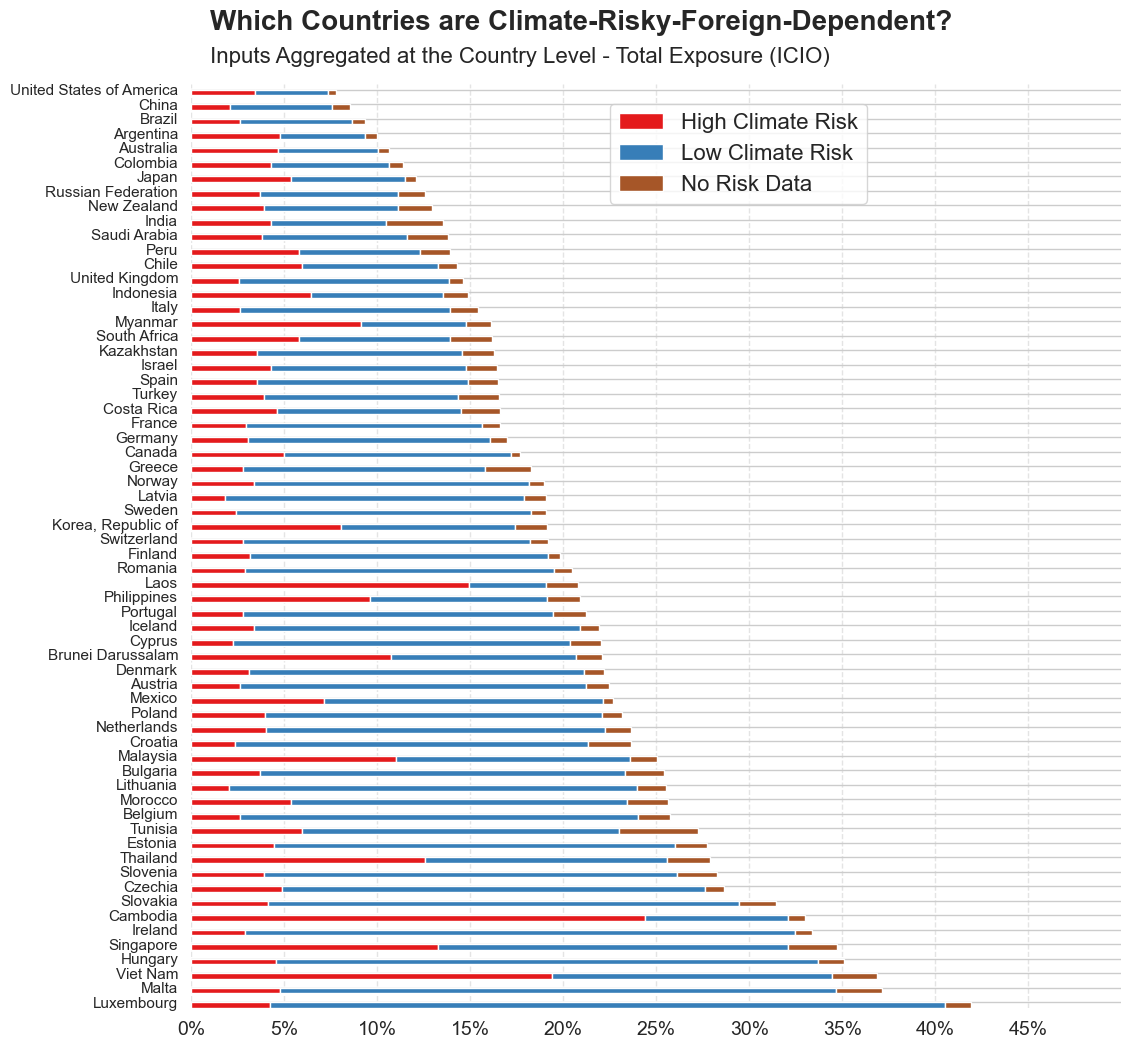

In [43]:
# Affichage par pays
######

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns  # Import seaborn for color palettes

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_inputs_leontief

result['Country'] = result['Country'].replace('United Kingdom of Great Britain and Northern Ireland', 'United Kingdom')
result['Country'] = result['Country'].replace("Lao People's Democratic Republic", 'Laos')
result['Country'] = result['Country'].replace("Taiwan, Province of China", 'Taiwan')

# Plotting
fig, ax = plt.subplots(figsize=(12, 12))

# Width of the bars
bar_width = 0.4

# Positions of the left bar-boundaries
bar_l = [i+1 for i in range(len(result['Country']))]

# Positions of the x-axis ticks (center of the bars as bar labels)
tick_pos = [i+(bar_width/2) for i in bar_l]

# Creating the bars

# Creating the bars

affichage = 'agrege'

if affichage == 'detail':
    # Create a color palette with harmonious colors
    color_palette = sns.color_palette("Set2", 7)

    ax.barh(bar_l, result['VLR (%)'], height=bar_width, label='Very low risk', color=color_palette[0], edgecolor='white')

    ax.barh(bar_l, result['LR (%)'], left=result['VLR (%)'], height=bar_width, label='Low risk', color=color_palette[1], edgecolor='white')

    ax.barh(bar_l, result['MR (%)'], left=result['VLR (%)']+result['LR (%)'], height=bar_width, label='Medium risk', color=color_palette[2], edgecolor='white')

    ax.barh(bar_l, result['HR (%)'], left=result['VLR (%)']+result['LR (%)']+result['MR (%)'], height=bar_width, label='High risk', color=color_palette[3], edgecolor='white')

    ax.barh(bar_l, result['VHR (%)'], left=result['VLR (%)']+result['LR (%)']+result['MR (%)']+result['HR (%)'], height=bar_width, label='Very high risk', color=color_palette[4], edgecolor='white')

    ax.barh(bar_l, result['ROW (%)'], left=result['VLR (%)']+result['LR (%)']+result['MR (%)']+result['HR (%)']+result['VHR (%)'], height=bar_width, label='ROW', color=color_palette[5], edgecolor='white')

    #ax.barh(bar_l, result['Local (%)'], left=result['High Risk']+result['Low Risk']+result['ROW (%)'], height=bar_width, label='Local', color='grey', edgecolor='white')

    
if affichage == 'agrege':
    # Create a color palette with harmonious colors
    color_palette = sns.color_palette("Set1", 7)

    ax.barh(bar_l, result['High Risk'], height=bar_width, label='High Climate Risk', color=color_palette[0], edgecolor='white')

    ax.barh(bar_l, result['Low Risk'], left=result['High Risk'], height=bar_width, label='Low Climate Risk', color=color_palette[1], edgecolor='white')

    ax.barh(bar_l, result['ROW (%)'], left=result['High Risk']+result['Low Risk'], height=bar_width, label='No Risk Data', color=color_palette[6], edgecolor='white')
    
    # Set bold title in the left corner
    plt.text(0.02, 1.08, "Which Countries are Climate-Risky-Foreign-Dependent?", transform=ax.transAxes, fontsize=20, fontweight='bold', va='top', ha='left')

    # Add a subtitle
    plt.text(0.02, 1.04, "Inputs Aggregated at the Country Level - Total Exposure (ICIO)", transform=ax.transAxes, fontsize=16, va='top', ha='left')


    #ax.barh(bar_l, result['Local (%)'], left=result['High Risk']+result['Low Risk']+result['ROW (%)'], height=bar_width, label='Local', color='grey', edgecolor='white')


        
if affichage == 'foreign':
    # Create a color palette with harmonious colors
    color_palette = sns.color_palette("Set2", 7)

    ax.barh(bar_l, result['Foreign (%)'], height=bar_width, label='Foreign Inputs', color='grey', edgecolor='white')
    # Set bold title in the left corner
    plt.text(0.02, 1.08, "Which Countries are Foreign Dependent?", transform=ax.transAxes, fontsize=20, fontweight='bold', va='top', ha='left')

    # Add a subtitle
    plt.text(0.02, 1.04, "Inputs Aggregated at the Country Level - Total Exposure (ICIO)", transform=ax.transAxes, fontsize=16, va='top', ha='left')


# Set the position of the x ticks
ax.set_yticks(tick_pos)

# Set the labels for the ticks
ax.set_yticklabels(result['Country'])


# Setting the x-axis and y-axis limits
plt.xlim([0,50])
plt.ylim([min(tick_pos)-bar_width, max(tick_pos)+bar_width])

# Adding the legend and title
plt.legend(loc=(0.45, 0.87),fontsize=16, frameon=True, facecolor='white')
# Set bold title in the left corner

# Suppress the frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Customize the x-axis ticks and labels
x_ticks = [0, 5, 10, 15, 20, 25, 30, 35, 40, 45]  # Define your desired x-axis tick positions
x_tick_labels = [str(x) + '%' for x in x_ticks]  # Convert positions to labels
# Customize the appearance of x-axis labels

# Set the x-axis ticks and labels
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_tick_labels)

# Customize the appearance of x-axis labels
plt.xticks(fontsize=14, rotation=0)  # Adjust the fontsize and rotation as needed

# Add light gray lines for x-axis labels
ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='lightgray')
plt.show()

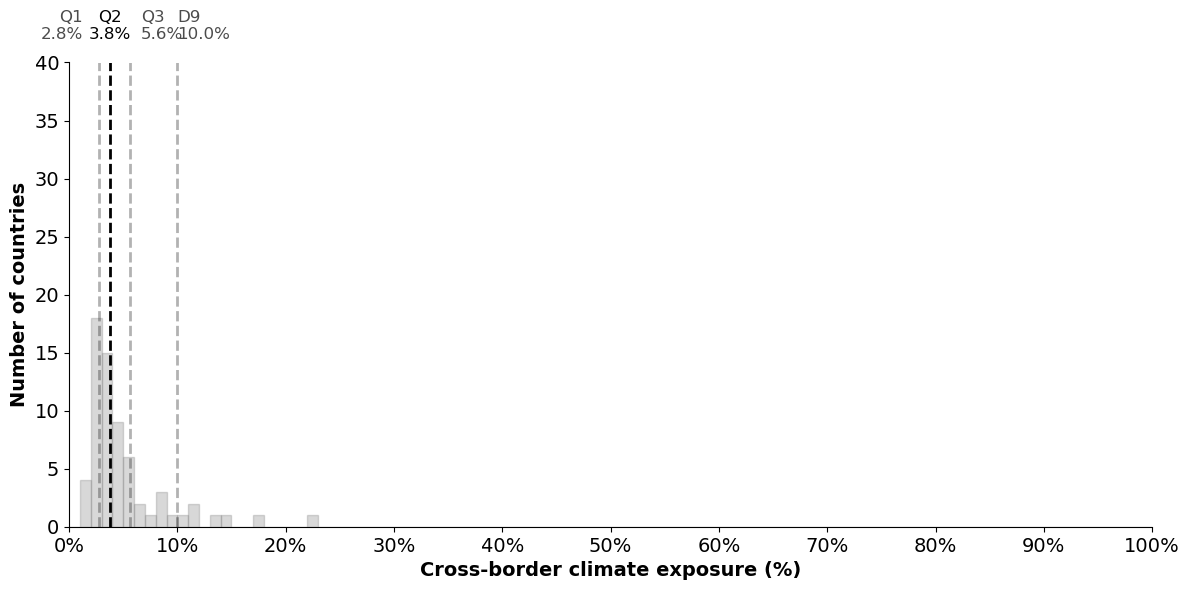

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

color_palette = sns.color_palette("Set1", 7)

# Define the number of bins and calculate the bin edges
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Count rows for the entire dataset
total_row_counts = count_rows_in_bins(df, bins, 'High Risk Exposure (%)')
data_to_plot = total_row_counts
color = 'grey'

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center', edgecolor='grey', alpha=0.3)

# Calculate and plot median and quartiles
flat_data = resulting_dataframe_country_inputs_leontief['High Risk Exposure (%)']
median_value = np.median(flat_data)
first_quartile = np.percentile(flat_data, 25)
third_quartile = np.percentile(flat_data, 75)
ninth_decile = np.percentile(flat_data, 90)

plt.axvline(median_value, color='black', linestyle='dashed', linewidth=2)
plt.axvline(first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
plt.axvline(third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
plt.axvline(ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)

# Annotate the lines
plt.text(median_value, 42 , f'Q2\n{median_value:.1f}%', horizontalalignment='center', color='black',fontsize=12)
plt.text(first_quartile-1.5, 42, f'Q1\n{first_quartile:.1f}%', horizontalalignment='right', color='black', alpha=0.7,fontsize=12)
plt.text(third_quartile+1, 42, f'Q3\n{third_quartile:.1f}%', horizontalalignment='left', color='black', alpha=0.7,fontsize=12)
plt.text(ninth_decile, 42, f'D9\n{ninth_decile:.1f}%', horizontalalignment='left', color='black', alpha=0.7,fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Titles
plt.xlabel('Cross-border climate exposure (%)',fontsize=14,fontweight='bold')
plt.ylabel('Number of countries',fontsize=14,fontweight='bold')

plt.xlim([0, 100])
plt.ylim([0, 40])

plt.tight_layout()

plt.savefig(r"Figures\Supp Mat\B\Fig1b.png")

plt.show()

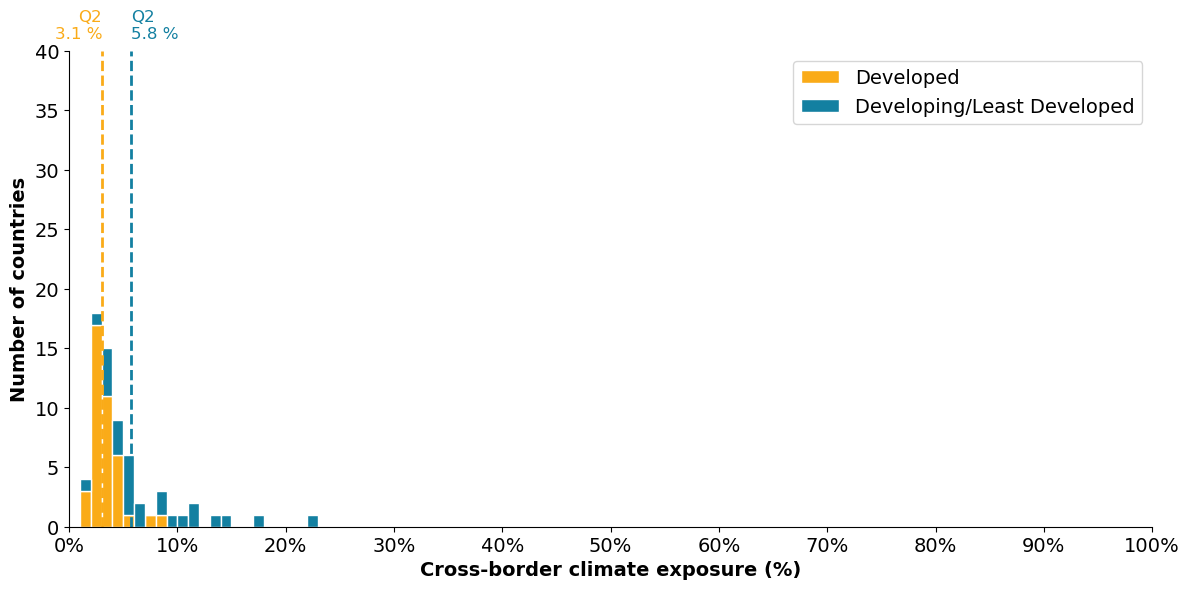

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

# Define the number of bins and calculate the bin edges
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Separate the data into two groups based on 'Development'
developed_df = df[df['Development'] == 'Developed']
not_developed_df = df[df['Development'] != 'Developed']
developed_row_counts = count_rows_in_bins(developed_df, bins, 'High Risk Exposure (%)')
not_developed_row_counts = count_rows_in_bins(not_developed_df, bins, 'High Risk Exposure (%)')
data_to_plot = [developed_row_counts, not_developed_row_counts]

# Custom colors for the bars
color = ['#FAAB18', '#1380A1']  # Orange for Developed, Blue for Developing/Least Developed
label = ['Developed', 'Developing/Least Developed']

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='white')
plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='white')
plt.legend()

# Calculate and plot median and quartiles for Developed countries
developed_flat_data = developed_df['High Risk Exposure (%)']
developed_median_value = np.median(developed_flat_data)
developed_first_quartile = np.percentile(developed_flat_data, 25)
developed_third_quartile = np.percentile(developed_flat_data, 75)

plt.axvline(developed_median_value, color=color[0], linestyle='dashed', linewidth=2)
#plt.axvline(developed_first_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(developed_third_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)

# Calculate and plot median and quartiles for Not Developed countries
not_developed_flat_data = not_developed_df['High Risk Exposure (%)']
not_developed_median_value = np.median(not_developed_flat_data)
not_developed_first_quartile = np.percentile(not_developed_flat_data, 25)
not_developed_third_quartile = np.percentile(not_developed_flat_data, 75)

plt.axvline(not_developed_median_value, color=color[1],  linestyle='dashed', linewidth=2)
#plt.axvline(not_developed_first_quartile, color=color[1], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(not_developed_third_quartile, color=color[1],linestyle='dashed', linewidth=2, alpha=0.3)

plt.text(not_developed_median_value, 41 , f'Q2\n{not_developed_median_value:.1f} %', horizontalalignment='left', color=color[1],fontsize=12)
plt.text(developed_median_value, 41, f'Q2\n{developed_median_value:.1f} %', horizontalalignment='right', color=color[0],fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Titles
plt.xlabel('Cross-border climate exposure (%)',fontsize=14, fontweight='bold')
plt.ylabel('Number of countries', fontsize=14, fontweight='bold')

plt.xlim([0, 100])
plt.ylim([0, 40])

plt.legend(fontsize=14)

plt.tight_layout()
plt.savefig(r"Figures\Supp Mat\B\Fig4b.png")

plt.show()

##### Distribution of Dependence to Foreign Countries

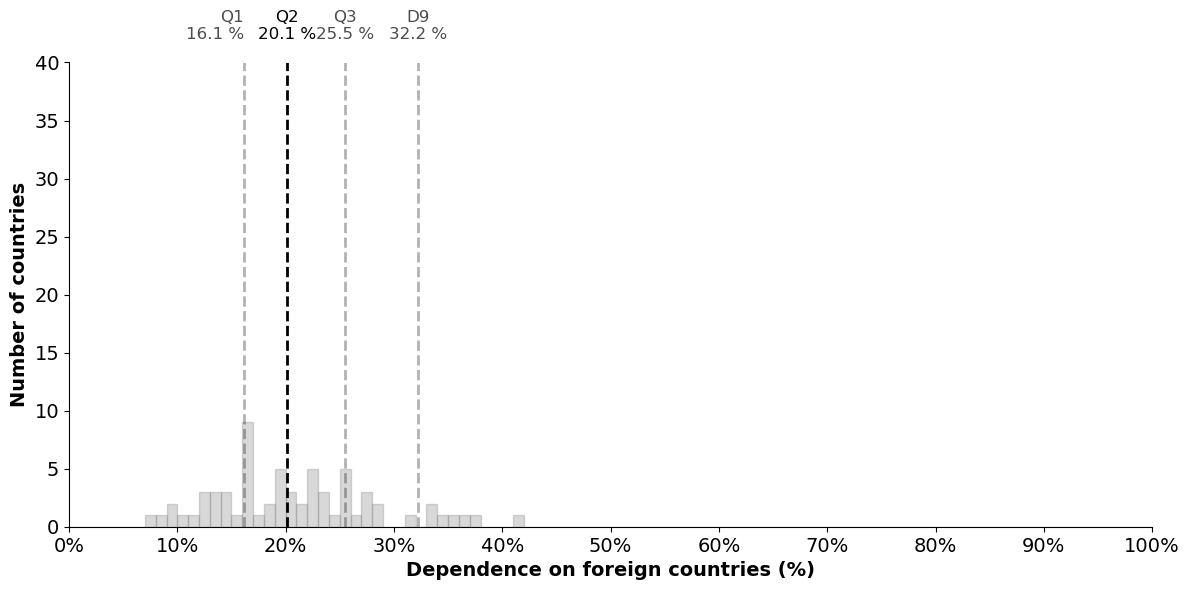

In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

color_palette = sns.color_palette("Set1", 7)

def plot_country_distribution(df, graph_type='total', x_max=None, y_max=None):
    """
    Plots the specified type of country distribution graph.

    :param df: DataFrame with the data.
    :param graph_type: Type of graph ('total' or 'risk_comparison').
    :param x_max: Maximum value for the x-axis.
    :param y_max: Maximum value for the y-axis.
    """
    # Define the number of bins and calculate the bin edges
    bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

    if graph_type == 'total':
        # Count rows for the entire dataset
        total_row_counts = count_rows_in_bins(df, bins, 'Foreign (%)')
        data_to_plot = total_row_counts
        color = 'grey'
        label = None
    elif graph_type == 'risk_comparison':
        # Separate the data into two groups based on 'Local Risk'
        low_risk_df = df[df['Local Risk'] == 'Low Risk']
        high_risk_df = df[df['Local Risk'] == 'Foreign (%)']
        low_risk_row_counts = count_rows_in_bins(low_risk_df, bins, 'Foreign (%)')
        high_risk_row_counts = count_rows_in_bins(high_risk_df, bins, 'Foreign (%)')
        data_to_plot = [low_risk_row_counts, high_risk_row_counts]
        color = [color_palette[1], color_palette[0]]
        label = ['Low Local Risk', 'High Local Risk']

    # Width of the bars
    bar_width = (bins[1] - bins[0])
    bar_positions = bins[:-1] + bar_width / 2

    # Create a plot
    plt.figure(figsize=(12, 6))

    if graph_type == 'total':
        plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center', edgecolor='grey', alpha=0.3)
    elif graph_type == 'risk_comparison':
        plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='grey')
        plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='grey')
        plt.legend()

    # Calculate and plot median and quartiles if data_to_plot is not None
    flat_data = resulting_dataframe_country_inputs_leontief['Foreign (%)']
    median_value = np.median(flat_data)
    first_quartile = np.percentile(flat_data, 25)
    third_quartile = np.percentile(flat_data, 75)
    ninth_decile = np.percentile(flat_data, 90)

    plt.axvline(median_value, color='black', linestyle='dashed', linewidth=2)
    plt.axvline(first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)

    # Annotate the lines
    plt.text(median_value, 42, f'Q2\n{median_value:.1f} %', horizontalalignment='center', color='black',fontsize=12)
    plt.text(first_quartile, 42, f'Q1\n{first_quartile:.1f} %', horizontalalignment='right', color='black', alpha=0.7,fontsize=12)
    plt.text(third_quartile, 42, f'Q3\n{third_quartile:.1f} %', horizontalalignment='center', color='black', alpha=0.7,fontsize=12)
    plt.text(ninth_decile, 42, f'D9\n{ninth_decile:.1f} %', horizontalalignment='center', color='black', alpha=0.7,fontsize=12)

    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels([f'{x}%' for x in custom_ticks])
    ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # Titles
    plt.xlabel('Dependence on foreign countries (%)',fontsize=14,fontweight='bold')
    plt.ylabel('Number of countries',fontsize=14,fontweight='bold')

    if x_max is not None:
        ax.set_xlim([0, x_max])
    if y_max is not None:
        ax.set_ylim([0, y_max])

    plt.tight_layout()
    plt.savefig(r"Figures\Supp Mat\B\Fig2b.png")

    plt.show()
        
# Usage examples
graph = "total" 
# graph='risk_comparison'
plot_country_distribution(df, graph_type=graph, x_max=100, y_max=40)

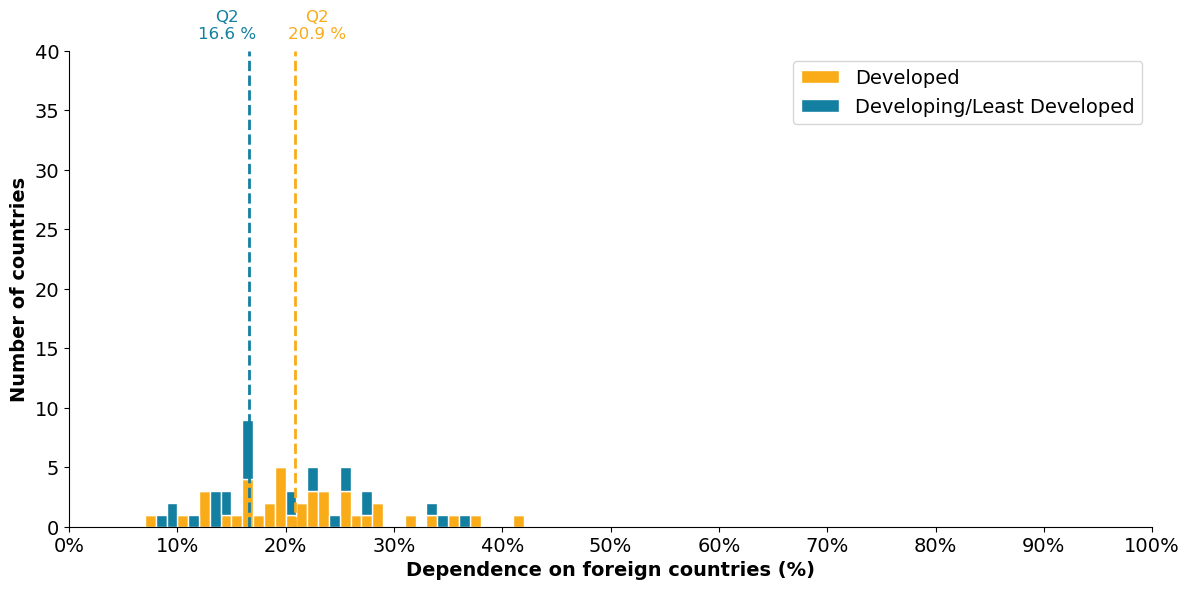

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

# Define the number of bins and calculate the bin edges
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Separate the data into two groups based on 'Development'
developed_df = df[df['Development'] == 'Developed']
not_developed_df = df[df['Development'] != 'Developed']
developed_row_counts = count_rows_in_bins(developed_df, bins, 'Foreign (%)')
not_developed_row_counts = count_rows_in_bins(not_developed_df, bins,  'Foreign (%)')
data_to_plot = [developed_row_counts, not_developed_row_counts]
# Custom colors for the bars
color = ['#FAAB18', '#1380A1']  # Orange for Developed, Blue for Developing/Least Developed
label = ['Developed', 'Developing/Least Developed']

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='white')
plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='white')
plt.legend()

# Calculate and plot median and quartiles for Developed countries
developed_flat_data = developed_df['Foreign (%)']
developed_median_value = np.median(developed_flat_data)
developed_first_quartile = np.percentile(developed_flat_data, 25)
developed_third_quartile = np.percentile(developed_flat_data, 75)

plt.axvline(developed_median_value, color=color[0], linestyle='dashed', linewidth=2)
#plt.axvline(developed_first_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(developed_third_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)

# Calculate and plot median and quartiles for Not Developed countries
not_developed_flat_data = not_developed_df['Foreign (%)']
not_developed_median_value = np.median(not_developed_flat_data)
not_developed_first_quartile = np.percentile(not_developed_flat_data, 25)
not_developed_third_quartile = np.percentile(not_developed_flat_data, 75)

plt.axvline(not_developed_median_value, color=color[1],  linestyle='dashed', linewidth=2)
#plt.axvline(not_developed_first_quartile, color=color[1], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(not_developed_third_quartile, color=color[1],linestyle='dashed', linewidth=2, alpha=0.3)
plt.text(not_developed_median_value-2, 41 , f'Q2\n{not_developed_median_value:.1f} %', horizontalalignment='center', color=color[1],fontsize=12)
plt.text(developed_median_value+2, 41, f'Q2\n{developed_median_value:.1f} %', horizontalalignment='center', color=color[0],fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Titles
plt.xlabel('Dependence on foreign countries (%)', fontsize=14, fontweight='bold')
plt.ylabel('Number of countries', fontsize=14, fontweight='bold')

plt.legend(fontsize=14)

plt.xlim([0, 100])
plt.ylim([0, 40])

plt.tight_layout()
plt.savefig(r"Figures\Supp Mat\B\Fig4f.png")

plt.show()

##### Distribution of Share of Risky Partners 
-----


In [72]:
resulting_dataframe_country_inputs_leontief

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%)
0,Luxembourg,LUX,1.2,Low Risk,Europe & Central Asia,High income,6.575690e+05,Developed,36.310338,4.236188,1.377742,41.924268,58.075732,10.447722
1,Malta,MLT,1.5,Low Risk,Middle East & North Africa,High income,5.249090e+05,Developed,29.882564,4.759419,2.493020,37.135002,62.864998,13.738875
2,Viet Nam,VNM,3.8,High Risk,East Asia & Pacific,Lower middle income,9.885895e+07,Developing,15.039706,19.383921,2.444455,36.868082,63.131918,56.309932
3,Hungary,HUN,1.8,Low Risk,Europe & Central Asia,High income,9.497333e+06,Developed,29.135656,4.551739,1.402983,35.090379,64.909621,13.511698
4,Singapore,SGP,0.7,Low Risk,East Asia & Pacific,High income,5.673743e+06,Developing,18.839907,13.262585,2.595798,34.698290,65.301710,41.313257
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,Australia,AUS,2.6,Low Risk,East Asia & Pacific,High income,2.623025e+07,Developed,5.361695,4.657195,0.603551,10.622441,89.377559,46.484139
62,Argentina,ARG,3.2,Low Risk,Latin America & Caribbean,Upper middle income,4.651925e+07,Developing,4.569929,4.772648,0.644251,9.986828,90.013172,51.084917
63,Brazil,BRA,5.1,High Risk,Latin America & Caribbean,Upper middle income,2.164224e+08,Developing,6.050728,2.599609,0.707288,9.357624,90.642376,30.052111
64,China,CHN,4.0,High Risk,East Asia & Pacific,Upper middle income,1.411878e+09,Developing,5.471844,2.078296,1.002568,8.552708,91.447292,27.526589


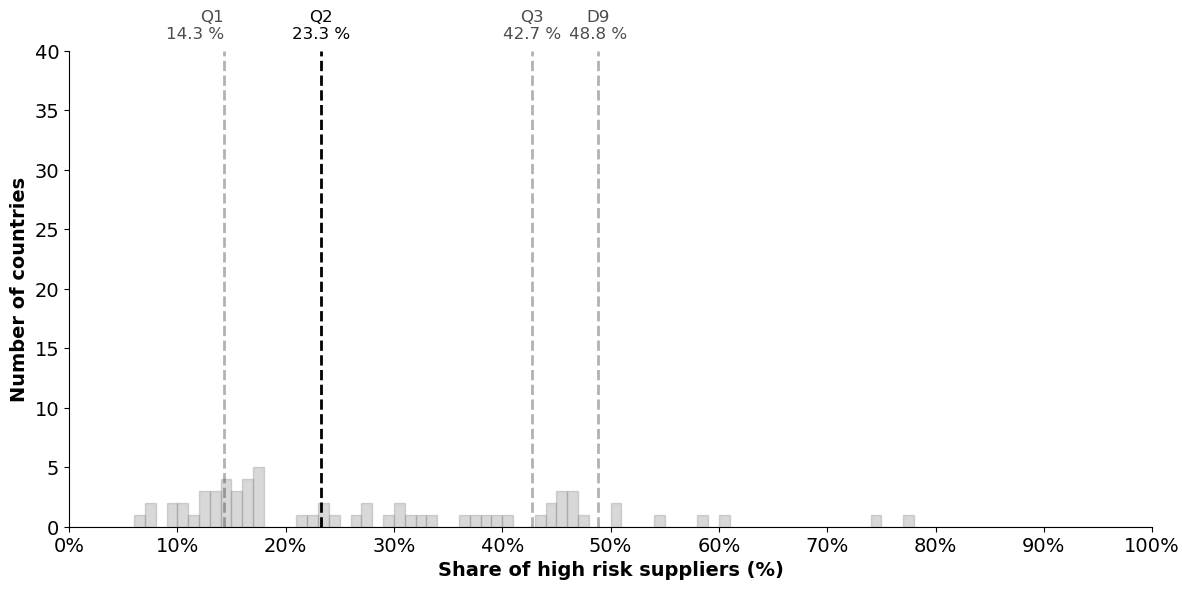

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

color_palette = sns.color_palette("Set1", 7)

def plot_country_distribution(df, graph_type='total', x_max=None, y_max=None):
    """
    Plots the specified type of country distribution graph.

    :param df: DataFrame with the data.
    :param graph_type: Type of graph ('total' or 'risk_comparison').
    :param x_max: Maximum value for the x-axis.
    :param y_max: Maximum value for the y-axis.
    """
    # Define the number of bins and calculate the bin edges
    bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

    if graph_type == 'total':
        # Count rows for the entire dataset
        total_row_counts = count_rows_in_bins(df, bins, 'Share of Risky Trade Partners (%)')
        data_to_plot = total_row_counts
        color = 'grey'
        label = None
    elif graph_type == 'risk_comparison':
        # Separate the data into two groups based on 'Local Risk'
        low_risk_df = df[df['Local Risk'] == 'Low Risk']
        high_risk_df = df[df['Local Risk'] == 'Share of Risky Trade Partners (%)']
        low_risk_row_counts = count_rows_in_bins(low_risk_df, bins, 'Share of Risky Trade Partners (%)')
        high_risk_row_counts = count_rows_in_bins(high_risk_df, bins, 'Share of Risky Trade Partners (%)')
        data_to_plot = [low_risk_row_counts, high_risk_row_counts]
        color = [color_palette[1], color_palette[0]]
        label = ['Low Local Risk', 'High Local Risk']

    # Width of the bars
    bar_width = (bins[1] - bins[0])
    bar_positions = bins[:-1] + bar_width / 2

    # Create a plot
    plt.figure(figsize=(12, 6))

    if graph_type == 'total':
        plt.bar(bar_positions, data_to_plot, width=bar_width, color=color, align='center', edgecolor='grey', alpha=0.3)
    elif graph_type == 'risk_comparison':
        plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='grey')
        plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='grey')
        plt.legend()

    # Calculate and plot median and quartiles if data_to_plot is not None
    flat_data = resulting_dataframe_country_inputs_leontief['Share of Risky Trade Partners (%)']
    median_value = np.median(flat_data)
    first_quartile = np.percentile(flat_data, 25)
    third_quartile = np.percentile(flat_data, 75)
    ninth_decile = np.percentile(flat_data, 90)

    plt.axvline(median_value, color='black', linestyle='dashed', linewidth=2)
    plt.axvline(first_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(third_quartile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)
    plt.axvline(ninth_decile, color='black', linestyle='dashed', linewidth=2, alpha=0.3)

    # Annotate the lines
    plt.text(median_value, 41, f'Q2\n{median_value:.1f} %', horizontalalignment='center', color='black',fontsize=12)
    plt.text(first_quartile, 41, f'Q1\n{first_quartile:.1f} %', horizontalalignment='right', color='black', alpha=0.7,fontsize=12)
    plt.text(third_quartile, 41, f'Q3\n{third_quartile:.1f} %', horizontalalignment='center', color='black', alpha=0.7,fontsize=12)
    plt.text(ninth_decile, 41, f'D9\n{ninth_decile:.1f} %', horizontalalignment='center', color='black', alpha=0.7,fontsize=12)

    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
    ax.set_xticks(custom_ticks)
    ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
    ax.tick_params(axis='y', labelsize=14)

    # Titles
    plt.xlabel('Share of high risk suppliers (%)',fontsize=14,fontweight='bold')
    plt.ylabel('Number of countries',fontsize=14,fontweight='bold')

    if x_max is not None:
        ax.set_xlim([0, x_max])
    if y_max is not None:
        ax.set_ylim([0, y_max])

    plt.tight_layout()
    plt.savefig(r"Figures\Supp Mat\B\Fig3b.png")

    plt.show()
        
# Usage examples
graph = "total" 
# graph='risk_comparison'
plot_country_distribution(df, graph_type=graph, x_max=100, y_max=40)

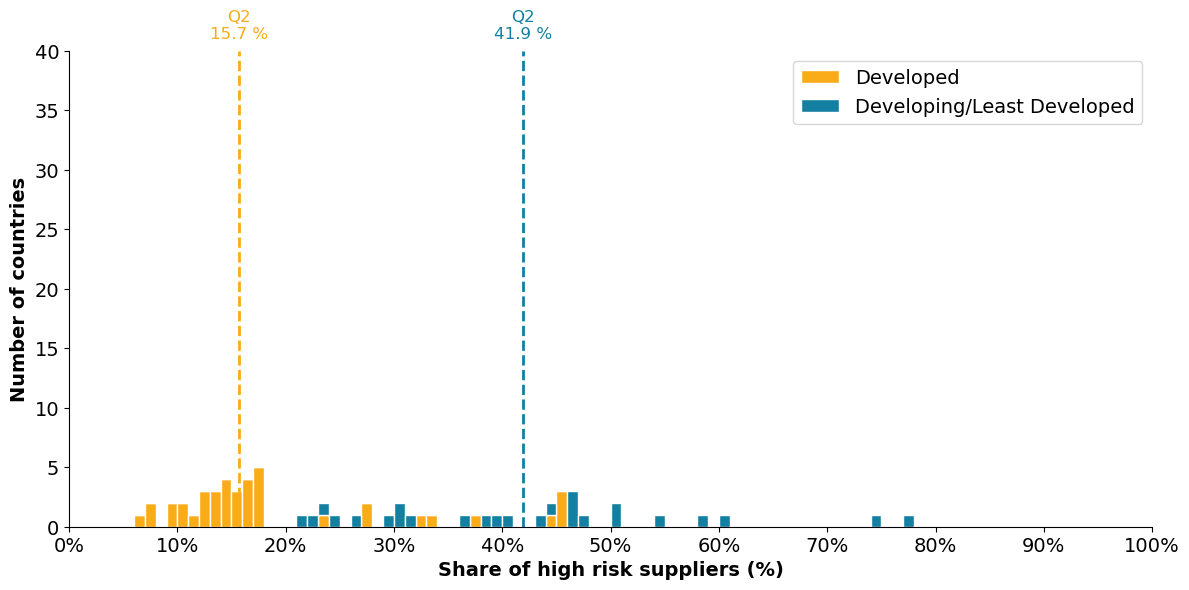

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Assuming df is your DataFrame
df = resulting_dataframe_country_inputs_leontief

# Define a function to count rows in bins
def count_rows_in_bins(d, bins, column_name):
    row_counts = []
    for i in range(len(bins) - 1):
        bin_d = d[(d[column_name] >= bins[i]) & (d[column_name] < bins[i + 1])]
        row_count = len(bin_d)
        row_counts.append(row_count)
    return row_counts

# Define the number of bins and calculate the bin edges
bins = np.arange(0, 101.5, 1)  # Stops at 105 to include the upper edge for 100%

# Separate the data into two groups based on 'Development'
developed_df = df[df['Development'] == 'Developed']
not_developed_df = df[df['Development'] != 'Developed']
developed_row_counts = count_rows_in_bins(developed_df, bins, 'Share of Risky Trade Partners (%)')
not_developed_row_counts = count_rows_in_bins(not_developed_df, bins, 'Share of Risky Trade Partners (%)')
data_to_plot = [developed_row_counts, not_developed_row_counts]
# Custom colors for the bars
color = ['#FAAB18', '#1380A1']  # Orange for Developed, Blue for Developing/Least Developed
label = ['Developed', 'Developing/Least Developed']

# Width of the bars
bar_width = (bins[1] - bins[0])
bar_positions = bins[:-1] + bar_width / 2

# Create a plot
plt.figure(figsize=(12, 6))
plt.bar(bar_positions, data_to_plot[0], width=bar_width, color=color[0], label=label[0], align='center', edgecolor='white')
plt.bar(bar_positions, data_to_plot[1], width=bar_width, color=color[1], label=label[1], bottom=data_to_plot[0], align='center', edgecolor='white')
plt.legend()

# Calculate and plot median and quartiles for Developed countries
developed_flat_data = developed_df['Share of Risky Trade Partners (%)']
developed_median_value = np.median(developed_flat_data)
developed_first_quartile = np.percentile(developed_flat_data, 25)
developed_third_quartile = np.percentile(developed_flat_data, 75)

plt.axvline(developed_median_value, color=color[0], linestyle='dashed', linewidth=2)
#plt.axvline(developed_first_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(developed_third_quartile, color=color[0], linestyle='dashed', linewidth=2, alpha=0.3)

# Calculate and plot median and quartiles for Not Developed countries
not_developed_flat_data = not_developed_df['Share of Risky Trade Partners (%)']
not_developed_median_value = np.median(not_developed_flat_data)
not_developed_first_quartile = np.percentile(not_developed_flat_data, 25)
not_developed_third_quartile = np.percentile(not_developed_flat_data, 75)

plt.axvline(not_developed_median_value, color=color[1],  linestyle='dashed', linewidth=2)
#plt.axvline(not_developed_first_quartile, color=color[1], linestyle='dashed', linewidth=2, alpha=0.3)
#plt.axvline(not_developed_third_quartile, color=color[1],linestyle='dashed', linewidth=2, alpha=0.3)
plt.text(not_developed_median_value, 41 , f'Q2\n{not_developed_median_value:.1f} %', horizontalalignment='center', color=color[1],fontsize=12)
plt.text(developed_median_value, 41, f'Q2\n{developed_median_value:.1f} %', horizontalalignment='center', color=color[0],fontsize=12)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

custom_ticks = [0, 10, 20, 30, 40, 50,60,70,80,90,100]
ax.set_xticks(custom_ticks)
ax.set_xticklabels([f'{x}%' for x in custom_ticks], fontsize=14)
ax.tick_params(axis='y', labelsize=14)

# Titles
plt.xlabel('Share of high risk suppliers (%)', fontsize=14, fontweight='bold')
plt.ylabel('Number of countries', fontsize=14, fontweight='bold')

plt.legend(fontsize=14)

plt.xlim([0, 100])
plt.ylim([0, 40])

plt.tight_layout()
plt.savefig(r"Figures\Supp Mat\B\Fig4d.png")

plt.show()

## Consumption
---

In [19]:
import pandas as pd

final_production = mriot.Y.copy()

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()

multi_index = pd.MultiIndex.from_product([country_list, country_list, sector_list], names=['No risk country', 'Country', 'Sector'])

Y = mriot.Y.copy()
# Group by the first level ('region') and sum values along columns for each 'region'
final_production_by_destination = Y.groupby(level='region', axis=1).sum()

values = {'Low Risk': [0] * multi_index.size}
risk_cs_low = pd.DataFrame(values, index=multi_index)

values = {'High Risk': [0] * multi_index.size}
risk_cs_high = pd.DataFrame(values, index=multi_index)

values = {'ROW': [0] * multi_index.size}
risk_cs_row = pd.DataFrame(values, index=multi_index)

for cc in country_list:   
    country_list_except = [x for x in country_list if x != cc]
    for c in country_list_except:
        for s in sector_list:
            final_production_cs=final_production_by_destination.loc[c,s]
            final_production_cs_tot = final_production_cs.sum()
            if final_production_cs_tot>0:
                risk_cs_low.loc[cc,c,s] = final_production_cs[~final_production_cs.index.isin([cc])&final_production_cs.index.isin(low_risk_countries)].sum() / final_production_cs_tot*100
                risk_cs_high.loc[cc,c,s] = final_production_cs[~final_production_cs.index.isin([cc])&final_production_cs.index.isin(high_risk_countries)].sum() / final_production_cs_tot*100
                risk_cs_row.loc[cc,c,s] = final_production_cs[~final_production_cs.index.isin([cc])&final_production_cs.index.isin(no_risk_countries)].sum() / final_production_cs_tot*100

    # List of DataFrames to concatenate
    risk_cs = [risk_cs_low, risk_cs_high,risk_cs_row]

    # Concatenate the DataFrames along columns (axis=1)
    risk_cs = pd.concat(risk_cs,axis=1)

C:\Users\delah\AppData\Local\Temp\ipykernel_2196\140244954.py:14: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  final_production_by_destination = Y.groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_2196\140244954.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '84.97909461088433' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  risk_cs_low.loc[cc,c,s] = final_production_cs[~final_production_cs.index.isin([cc])&final_production_cs.index.isin(low_risk_countries)].sum() / final_production_cs_tot*100
C:\Users\delah\AppData\Local\Temp\ipykernel_2196\140244954.py:33: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '10.712175962690388' has dtype incompatible with int64, please explicitly cast to a compatible dtype fi

In [20]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/risk_cs_consumption_leontief_icio.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(risk_cs, f)

In [ ]:
import pickle
import pandas as pd


# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/risk_cs_consumption_leontief_icio.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    risk_cs = pickle.load(f)
    
# Assuming 'df' is your DataFrame
risk_cs.index.names = ['region' if name == 'Country' else 'sector' if name == 'Sector' else name for name in risk_cs.index.names]

In [30]:
import pandas as pd

final_production_by_use = mriot.Y.copy()
y = final_production_by_use.sum(axis = 1) # final production of (c,s), whatever use

Y = final_production_by_use.T.groupby('region').sum().T

x = mriot.x # Gross output

L= mriot.L # Leontief matrix

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * country_list.size}
cConsoFin_low = pd.DataFrame(values, index=country_list)

values = {'High Risk': [0] * country_list.size}
cConsoFin_high = pd.DataFrame(values, index=country_list)

values = {'ROW': [0] * country_list.size}
cConsoFin_row = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cConsoFin_Foreign = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cConsoFin_Local = pd.DataFrame(values, index=country_list)

for cc in country_list:
    Y_cc = Y[cc]
    Y_cc_tot = Y_cc.sum()
    country_list_except = [x for x in country_list if x != cc]

    for c in country_list_except:
        for s in sector_list:
            cConsoFin_low.loc[cc] = cConsoFin_low.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['Low Risk']/100
            cConsoFin_high.loc[cc] = cConsoFin_high.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['High Risk']/100
            cConsoFin_row.loc[cc] = cConsoFin_row.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['ROW']/100

    cConsoFin_Foreign.loc[cc] = cConsoFin_low.loc[cc].iloc[0] + cConsoFin_high.loc[cc].iloc[0] + cConsoFin_row.loc[cc].iloc[0]
    cConsoFin_Local.loc[cc] = Y_cc_tot - cConsoFin_Foreign.loc[cc].iloc[0]

    #Ratios
    cConsoFin_low.loc[cc]=cConsoFin_low.loc[cc].iloc[0]/Y_cc_tot*100
    cConsoFin_high.loc[cc]=cConsoFin_high.loc[cc].iloc[0]/Y_cc_tot*100
    cConsoFin_row.loc[cc]=cConsoFin_row.loc[cc].iloc[0]/Y_cc_tot*100

    cConsoFin_Local.loc[cc]=cConsoFin_Local.loc[cc].iloc[0]/Y_cc_tot*100
    cConsoFin_Foreign.loc[cc]=cConsoFin_Foreign.loc[cc].iloc[0]/Y_cc_tot*100
    
# List of DataFrames to concatenate
dataframes_to_concat = [cConsoFin_low, cConsoFin_high,cConsoFin_row, cConsoFin_Foreign, cConsoFin_Local]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_cons_leontief = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_cons_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_country_cons_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_2196\860273869.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.79647166298619' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cConsoFin_low.loc[cc] = cConsoFin_low.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['Low Risk']/100
C:\Users\delah\AppData\Local\Temp\ipykernel_2196\860273869.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.10040051194087342' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cConsoFin_high.loc[cc] = cConsoFin_high.loc[cc].iloc[0]+Y_cc.loc[c,s]*risk_cs.loc[cc,c,s]['High Risk']/100
C:\Users\delah\AppData\Local\Temp\ipykernel_2196\860273869.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.04033682952749085'

In [44]:
resulting_dataframe_country_cons_leontief

,Country,Country Code,Climate Risk,Local Risk,Region,Income group,Population,Development,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%)
0,Ireland,IRL,1.7,Low Risk,Europe & Central Asia,High income,5.120455e+06,Developed,34.949763,3.188358,1.337960,39.476081,60.523919,8.360028
1,Hong Kong,HKG,4.0,High Risk,East Asia & Pacific,High income,7.350409e+06,Developing,14.087451,18.395290,1.276103,33.758844,66.241156,56.630966
2,Malta,MLT,1.5,Low Risk,Middle East & North Africa,High income,5.249090e+05,Developed,26.911566,4.259513,2.288507,33.459586,66.540414,13.664952
3,Cambodia,KHM,5.2,High Risk,East Asia & Pacific,Lower middle income,1.694483e+07,Least Developed,9.255928,22.698597,1.100414,33.054939,66.945061,71.034061
4,Singapore,SGP,0.7,Low Risk,East Asia & Pacific,High income,5.673743e+06,Developing,17.109945,12.529534,2.510136,32.149616,67.850384,42.273125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,Indonesia,IDN,4.7,High Risk,East Asia & Pacific,Upper middle income,2.775341e+08,Developing,4.623254,3.700989,0.575764,8.900007,91.099993,44.460367
62,United States of America,USA,3.2,Low Risk,North America,High income,3.350210e+08,Developed,3.393368,3.068750,0.384506,6.846624,93.153376,47.488304
63,Japan,JPN,2.3,Low Risk,East Asia & Pacific,High income,1.243894e+08,Developed,3.219241,3.096701,0.255450,6.571393,93.428607,49.029917
64,Brazil,BRA,5.1,High Risk,Latin America & Caribbean,Upper middle income,2.164224e+08,Developing,4.264454,1.860932,0.389663,6.515049,93.484951,30.380647


In [32]:
import pickle as pkl
# Specify the file path where you want to save the object
file_path = r"INFORM_Climate_Change\results\resulting_dataframe_country_cons_leontief_icio.pkl"

# Open the file with write-binary ('wb') mode and save the object
with open(file_path, "wb") as f:
    pkl.dump(resulting_dataframe_country_cons_leontief, f)

In [26]:
import pickle as pkl
# Specify the file path where you want to save the object
file_path = r"INFORM_Climate_Change\results\resulting_dataframe_country_cons_leontief_icio.pkl"

# Open the file with write-binary ('wb') mode and save the object
with open(file_path, "rb") as f:
    resulting_dataframe_country_cons_leontief = pkl.load(f)

In [33]:
df=resulting_dataframe_country_cons_leontief
median_high_risk_developed_consumption = df[df['Development'] == 'Developed']['High Risk Exposure (%)'].median()
#median_high_risk_developed = df[df['Region'] == 'Europe & Central Asia']['High Risk'].median()
median_high_risk_developed_consumption

2.6367811557816476

## Exports

### Inputs

In [19]:
import pandas as pd

Y = mriot.Y.copy()
x = mriot.x
y = Y.sum(axis = 1)

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * country_list.size}
cExports_low = pd.DataFrame(values, index=country_list)

values = {'High Risk': [0] * country_list.size}
cExports_high = pd.DataFrame(values, index=country_list)

values = {'ROW': [0] * country_list.size}
cExports_row = pd.DataFrame(values, index=country_list)

values = {'Foreign (%)': [0] * country_list.size}
cExports = pd.DataFrame(values, index=country_list)

values = {'Local (%)': [0] * country_list.size}
cLocal_Use = pd.DataFrame(values, index=country_list)

for c in country_list:
    exports_c = 0
    exports_c_low = 0
    exports_c_high = 0
    exports_c_row = 0

    y_c = y[~y.index.get_level_values('region').isin([c])]
    y_c_low = y[~y.index.get_level_values('region').isin([c]) & y.index.get_level_values('region').isin(low_risk_countries)]
    y_c_high = y[~y.index.get_level_values('region').isin([c]) & y.index.get_level_values('region').isin(high_risk_countries)]
    y_c_row = y[~y.index.get_level_values('region').isin([c]) & y.index.get_level_values('region').isin(no_risk_countries)]

    x_c= x.loc[c].sum().iloc[0]

    for s in sector_list:
        L_cs = L.loc[c,s]
        
        L_cs = L_cs[L_cs.index.get_level_values('region') != c]
        L_cs_foreign_low = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(low_risk_countries)]
        L_cs_foreign_high = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(high_risk_countries)]
        L_cs_foreign_row = L_cs[~L_cs.index.get_level_values('region').isin([c]) & L_cs.index.get_level_values('region').isin(no_risk_countries)]

        exports_cs = (L_cs*y_c).sum()
        exports_cs_low = (L_cs_foreign_low*y_c_low).sum()
        exports_cs_high = (L_cs_foreign_high*y_c_high).sum()
        exports_cs_row = (L_cs_foreign_row*y_c_row).sum()

        exports_c = exports_c + exports_cs
        exports_c_low = exports_c_low + exports_cs_low
        exports_c_high = exports_c_high + exports_cs_high
        exports_c_row = exports_c_row + exports_cs_row


    cExports.loc[c] = exports_c / x_c*100
    cExports_low.loc[c] = exports_c_low / x_c*100
    cExports_high.loc[c] = exports_c_high / x_c *100
    cExports_row.loc[c] = exports_c_row / x_c *100

    
    cLocal_Use.loc[c] = 100 - cExports.loc[c].iloc[0]
    
# List of DataFrames to concatenate
dataframes_to_concat = [cExports_low, cExports_high,cExports_row, cExports, cLocal_Use]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_country_exports_leontief_CI = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_country_exports_leontief_CI.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_country_exports_leontief_CI = result

C:\Users\delah\AppData\Local\Temp\ipykernel_16884\1560160571.py:60: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '8.00766708635492' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports.loc[c] = exports_c / x_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_16884\1560160571.py:61: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '3.338757065909723' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_low.loc[c] = exports_c_low / x_c*100
C:\Users\delah\AppData\Local\Temp\ipykernel_16884\1560160571.py:62: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '3.705440430693131' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  cExports_high.loc[c] = exports_c_hi

In [20]:
import pickle as pkl
# Specify the file path where you want to save the object
file_path = r"INFORM_Climate_Change\results\resulting_dataframe_country_exports_leontief_icio.pkl"

# Open the file with write-binary ('wb') mode and save the object
#with open(file_path, "wb") as f:
    pkl.dump(resulting_dataframe_country_exports_leontief_CI, f)

In [ ]:
import pickle as pkl
# Specify the file path where you want to save the object
file_path = r"INFORM_Climate_Change\results\resulting_dataframe_country_exports_leontief_icio.pkl"

# Open the file with write-binary ('wb') mode and save the object
with open(file_path, "rb") as f:
    resulting_dataframe_country_exports_leontief_CI = pkl.load(f)

In [21]:
df=resulting_dataframe_country_exports_leontief_CI
median_high_risk_developed_exports_inputs = df[df['Development'] == 'Developed']['High Risk Exposure (%)'].median()

median_high_risk_developed_exports_inputs

3.308142141149821

# Sector-level analysis
-----

## Inputs
-----

### Code
-----

#### By sector

Backward exposure of (c,s) as an economic sector, on intermediary consumption

In [33]:
import pandas as pd    

Y = mriot.Y.copy()
x = mriot.x
y = Y.sum(axis = 1)

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()

index_cs = mriot.x.index

values = {'Low Risk': [0] * index_cs.size}
Foreign_Inputs_low = pd.DataFrame(values, index=index_cs)

values = {'High Risk': [0] * index_cs.size}
Foreign_Inputs_high = pd.DataFrame(values, index=index_cs)

values = {'ROW': [0] * index_cs.size}
Foreign_Inputs_ROW = pd.DataFrame(values, index=index_cs)

values = {'Local (%)': [0] * index_cs.size}
Local_Inputs = pd.DataFrame(values, index=index_cs)

values = {'Foreign (%)': [0] * index_cs.size}
Foreign_Inputs = pd.DataFrame(values, index=index_cs)

for s in sector_list:  
    for c in country_list:
        L_cs =L[c,s]
        y_cs=y[c,s]
        inputs_cs = (L_cs*y_cs).sum()  # inputs used by sector (c,s)

        if inputs_cs != 0 :
            Foreign_Inputs.loc[c,s]= (L_cs[~L_cs.index.get_level_values('region').isin([c])]*y_cs).sum()/inputs_cs*100
            Local_Inputs.loc[c,s] = (L_cs[L_cs.index.get_level_values('region').isin([c])]*y_cs).sum()/inputs_cs*100
            Foreign_Inputs_low.loc[c,s] =  (L_cs[~L_cs.index.get_level_values('region').isin([c])&L_cs.index.get_level_values('region').isin(low_risk_countries)]*y_cs).sum()/inputs_cs*100
            Foreign_Inputs_high.loc[c,s] = (L_cs[~L_cs.index.get_level_values('region').isin([c])&L_cs.index.get_level_values('region').isin(high_risk_countries)]*y_cs).sum()/inputs_cs*100
            Foreign_Inputs_ROW.loc[c,s] = (L_cs[~L_cs.index.get_level_values('region').isin([c])&L_cs.index.get_level_values('region').isin(no_risk_countries)]*y_cs).sum()/inputs_cs*100

# List of DataFrames to concatenate
dataframes_to_concat = [Foreign_Inputs_low, Foreign_Inputs_high, Foreign_Inputs_ROW,Foreign_Inputs, Local_Inputs]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_sectors_inputs_leontief_sector = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_sectors_inputs_leontief_sector.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development','sector', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_sectors_inputs_leontief_sector=result

C:\Users\delah\AppData\Local\Temp\ipykernel_16884\1145645353.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '7.502888423760624' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Foreign_Inputs.loc[c,s]= (L_cs[~L_cs.index.get_level_values('region').isin([c])]*y_cs).sum()/inputs_cs*100
C:\Users\delah\AppData\Local\Temp\ipykernel_16884\1145645353.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '92.49711157623935' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Local_Inputs.loc[c,s] = (L_cs[L_cs.index.get_level_values('region').isin([c])]*y_cs).sum()/inputs_cs*100
C:\Users\delah\AppData\Local\Temp\ipykernel_16884\1145645353.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '3.465064058104

#### By product

Backward exposure of the whole economy of c on good s as intermediary consumption

In [35]:
import pandas as pd    

Y = mriot.Y.copy()
x = mriot.x
y = Y.sum(axis = 1)

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()

index_cs = mriot.x.index

values = {'Low Risk': [0] * index_cs.size}
Foreign_Inputs_low = pd.DataFrame(values, index=index_cs)

values = {'High Risk': [0] * index_cs.size}
Foreign_Inputs_high = pd.DataFrame(values, index=index_cs)

values = {'ROW': [0] * index_cs.size}
Foreign_Inputs_ROW = pd.DataFrame(values, index=index_cs)

values = {'Local (%)': [0] * index_cs.size}
Local_Inputs = pd.DataFrame(values, index=index_cs)

values = {'Foreign (%)': [0] * index_cs.size}
Foreign_Inputs = pd.DataFrame(values, index=index_cs)


for s in sector_list:    
    for c in country_list:
        L_c = L[c]
        y_c = y[c]
        
        inputs_cs = L_c.groupby('sector').sum().loc[s].dot(y_c)  # products s used as inputs for all sectors of c's economy
        
        if (inputs_cs != 0) & (y_c[s]>0) :
            Foreign_Inputs.loc[c,s]= L_c.loc[~L_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
            Local_Inputs.loc[c,s] = L_c.loc[L_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
            Foreign_Inputs_low.loc[c,s] =  L_c.loc[~L_c.index.get_level_values('region').isin([c]) & L_c.index.get_level_values('region').isin(low_risk_countries)].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
            Foreign_Inputs_high.loc[c,s] = L_c.loc[~L_c.index.get_level_values('region').isin([c]) & L_c.index.get_level_values('region').isin(high_risk_countries)].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
            Foreign_Inputs_ROW.loc[c,s] = L_c.loc[~L_c.index.get_level_values('region').isin([c]) & L_c.index.get_level_values('region').isin(no_risk_countries)].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100

# List of DataFrames to concatenate
dataframes_to_concat = [Foreign_Inputs_low, Foreign_Inputs_high, Foreign_Inputs_ROW,Foreign_Inputs, Local_Inputs]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_sectors_inputs_leontief = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_sectors_inputs_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development','sector', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_sectors_inputs_leontief=result

C:\Users\delah\AppData\Local\Temp\ipykernel_16884\4002979630.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '4.212889118488039' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Foreign_Inputs.loc[c,s]= L_c.loc[~L_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
C:\Users\delah\AppData\Local\Temp\ipykernel_16884\4002979630.py:39: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '95.78711088151195' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Local_Inputs.loc[c,s] = L_c.loc[L_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s].dot(y_c)/inputs_cs*100
C:\Users\delah\AppData\Local\Temp\ipykernel_16884\4002979630.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and wil

In [12]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/resulting_dataframe_sectors_inputs_leontief_icio.pkl'

# Save the dictionary to a file
with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_sectors_inputs_leontief, f)

In [13]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/resulting_dataframe_sectors_inputs_leontief_icio.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_sectors_inputs_leontief = pickle.load(f)

### Plot
----

median_high_risk_developed_inputs should be generated in Country-level analysis Inputs

Number of outliers: 151
Outlier values: [18.574357445712504, 24.616468901696834, 18.402071872984813, 17.429340356188618, 21.636323435911212, 23.571096557120466, 17.99698891953977, 32.5608366562134, 41.80584756769996, 23.400820895815215, 41.926904937186976, 35.95399594251318, 18.771098178637747, 40.29840898104297, 48.9489513742018, 18.598412697381274, 31.62450500722853, 21.639934295244704, 41.6588892455763, 28.72525729976773, 18.497290749684794, 17.787964686829415, 26.33819343027655, 17.39264708403044, 30.451619066226492, 28.178941940194917, 19.254001974335218, 19.204214453092362, 18.39326499229861, 34.342484311361474, 17.746109099889264, 23.33037821556816, 21.100822548755243, 24.337322619452955, 45.24300829822289, 24.115753753574896, 45.590582877321594, 32.217255546096446, 19.506226785093055, 21.39213427448549, 28.094492001520372, 23.433471963813027, 21.793666001563718, 27.147109609177722, 29.94053463108069, 18.37208663056426, 23.142936473720216, 25.87934492852384, 47.04458050521853, 2

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


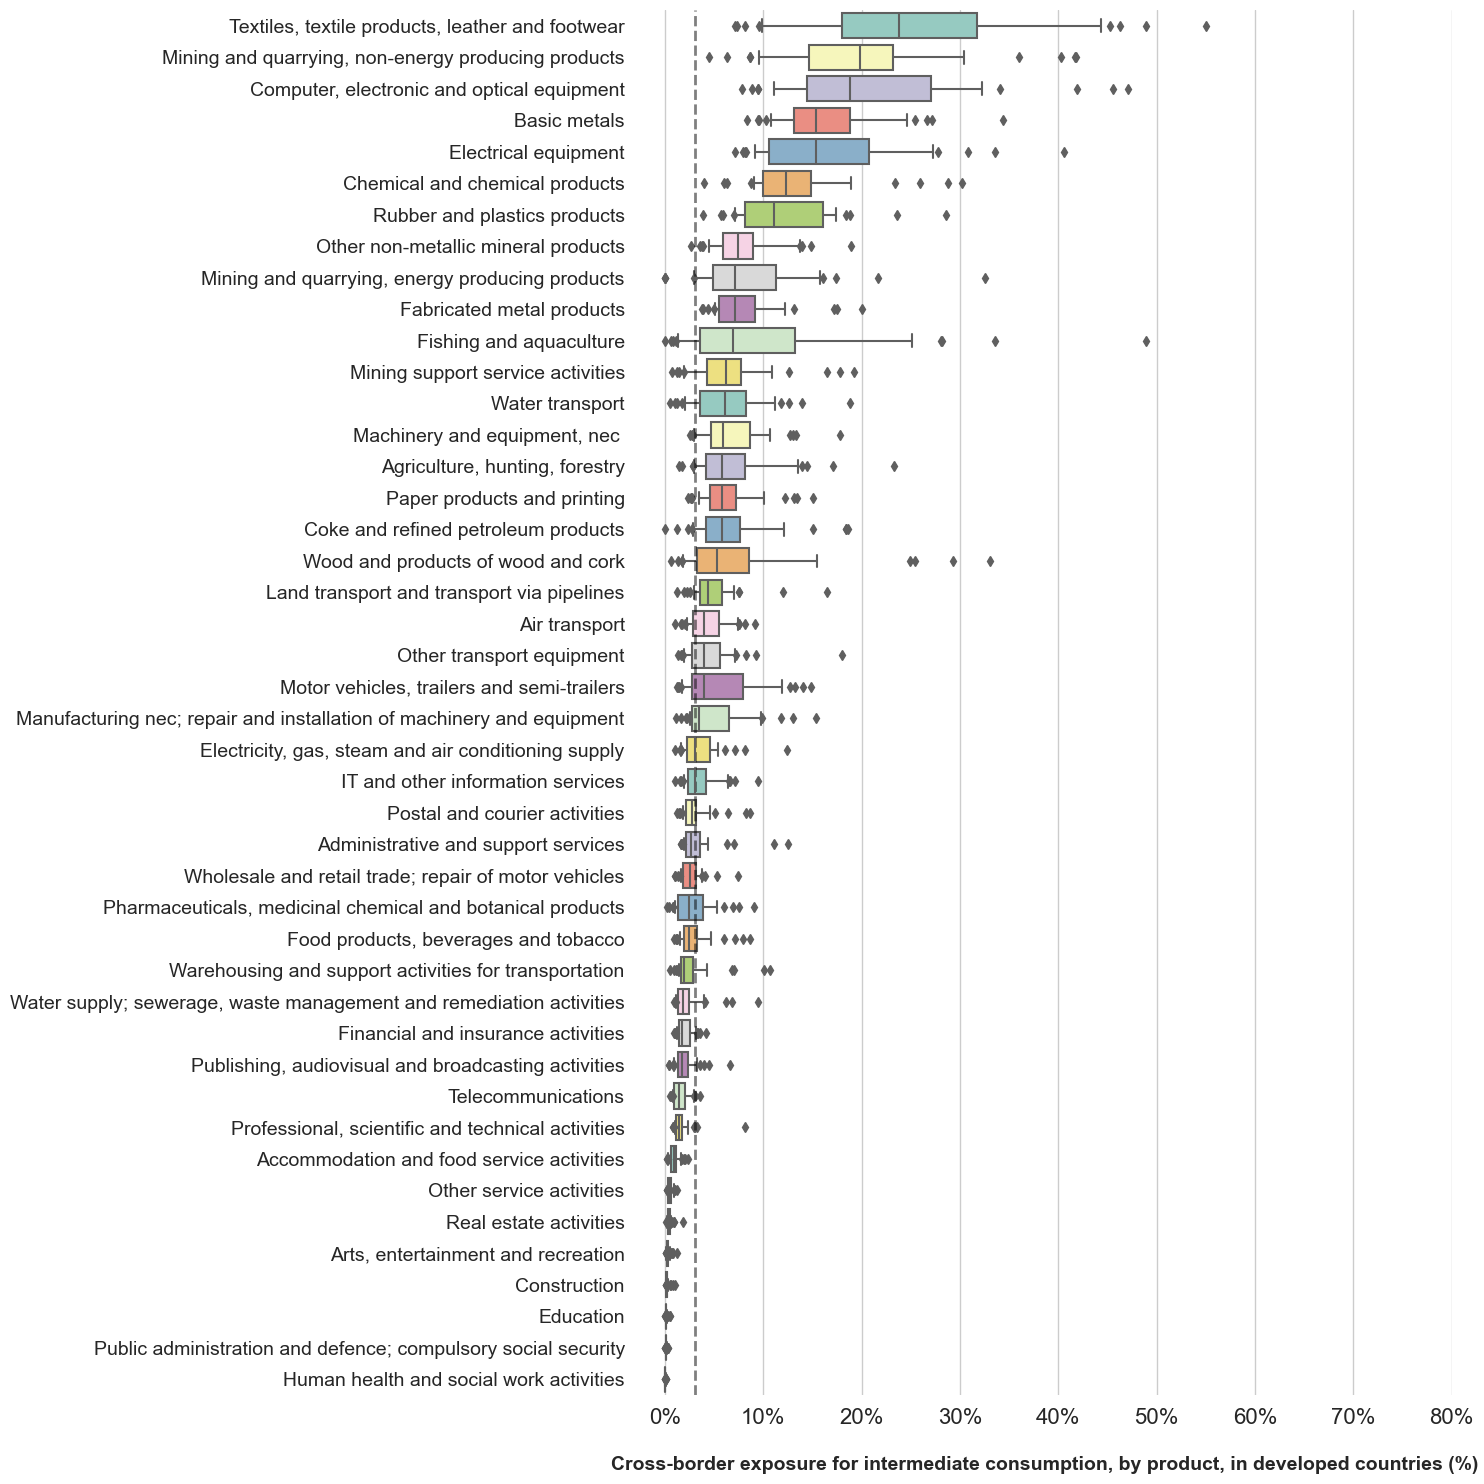

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming your dataframe is loaded as df
df = resulting_dataframe_sectors_inputs_leontief
#df = resulting_dataframe_sectors_inputs_leontief_sector
# Split the data
df_developed = df[df['Development'] == 'Developed']

# Calculate the IQR and determine outliers manually
Q1 = df_developed['High Risk Exposure (%)'].quantile(0.25)
Q3 = df_developed['High Risk Exposure (%)'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_developed[(df_developed['High Risk Exposure (%)'] < (Q1 - 1.5 * IQR)) | (df_developed['High Risk Exposure (%)'] > (Q3 + 1.5 * IQR))]

print("Number of outliers:", len(outliers))
print("Outlier values:", outliers['High Risk Exposure (%)'].tolist())

# Calculate the median 'High Risk Exposure (%)' for each sector in developed countries
sector_medians_developed = df_developed.groupby('sector')['High Risk Exposure (%)'].median()
sector_medians_developed = sector_medians_developed.sort_values(ascending=False)

# Set the threshold for median
threshold = 0  # Adjust this threshold as needed

# Filter sectors based on the threshold
selected_sectors = sector_medians_developed[sector_medians_developed > threshold].index
# Sort the sectors by these medians in descending order
sorted_sectors = sector_medians_developed.sort_values(ascending=False).index

# Set the style for the plots
sns.set(style="whitegrid")

# Create a figure and axes
fig, ax = plt.subplots(figsize=(15, 15))

# Create the boxplot with horizontal orientation for selected sectors
sns.boxplot(y='sector', x='High Risk Exposure (%)', data=df_developed[df_developed['sector'].isin(selected_sectors)], ax=ax,
            order=selected_sectors, orient='h', palette="Set3",whis=[10, 90])


# Annotations and aesthetics
ax.axvline(x=median_high_risk_developed_inputs, color='black', linestyle='--', linewidth=2, alpha=0.5)

# Suppress the y-axis label
ax.set_ylabel('')

# Suppress the frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Customize x-axis
x_ticks = np.linspace(0, 80, 9)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f'{x:.0f}%' for x in x_ticks], fontsize=16)

# Customize y-axis
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)

# Set x-axis label
ax.set_xlabel('Cross-border exposure for intermediate consumption, by product, in developed countries (%)', fontsize=14, fontweight='bold', labelpad=20)

plt.tight_layout()
#plt.savefig(r"Figures\Supp Mat\D\Fig2a.png")
#plt.savefig(r"Figures\Supp Mat\D\Fig4a.png")

plt.show()

In [46]:
# Assuming your dataframe is loaded as df
df = resulting_dataframe_sectors_inputs_leontief
# Split the data
df_developed = df[df['Development'] == 'Developed']
# Calculate the median 'High Risk' for each sector in developed countries
sector_medians_developed = df_developed.groupby('sector')['High Risk Exposure (%)'].median()
sector_medians_developed = sector_medians_developed.sort_values(ascending=False)
sector_medians_developed

sector
Textiles, textile products, leather and footwear                                                                              23.772578
Mining and quarrying, non-energy producing products                                                                           19.784843
Computer, electronic and optical equipment                                                                                    18.796674
Basic metals                                                                                                                  15.388493
Electrical equipment                                                                                                          15.323097
Chemical and chemical products                                                                                                12.316808
Rubber and plastics products                                                                                                  11.133126
Other non-metallic mineral products      

Median by sector : 

In [68]:
df_developed

,Country,sector,Local Risk,Index 2050 (RCP8.5),Change in Risk,Region,Income group,Population (2023),Development,VLR (%),LR (%),MR (%),HR (%),VHR (%),ROW (%),Foreign (%),Local (%),Low Risk,High Risk,High Risk (relative)
53,Australia,"Agriculture, hunting, forestry",Low Risk,2.6,0.2,East Asia & Pacific,High income,26230248.0,Developed,0.616083,1.606857,1.068919,0.377087,0,0.845251,NaN,NaN,2.222940,1.446006,39.412018
54,Australia,Fishing and aquaculture,Low Risk,2.6,0.2,East Asia & Pacific,High income,26230248.0,Developed,2.393534,0.774983,0.470101,0.070656,0,0.881918,NaN,NaN,3.168517,0.540757,14.578521
55,Australia,"Mining and quarrying, energy producing products",Low Risk,2.6,0.2,East Asia & Pacific,High income,26230248.0,Developed,2.583044,2.916552,10.352355,0.109926,0,6.811875,NaN,NaN,5.499596,10.462281,65.545433
56,Australia,"Mining and quarrying, non-energy producing pro...",Low Risk,2.6,0.2,East Asia & Pacific,High income,26230248.0,Developed,0.125422,0.446920,0.125068,0.010290,0,0.025487,NaN,NaN,0.572342,0.135358,19.126485
57,Australia,Mining support service activities,Low Risk,2.6,0.2,East Asia & Pacific,High income,26230248.0,Developed,0.184523,0.415025,0.055475,0.040439,0,0.021940,NaN,NaN,0.599548,0.095914,13.791418
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2919,United States of America,Public administration and defence; compulsory ...,Low Risk,3.2,0.1,North America,High income,335020960.0,Developed,0.014973,0.052206,0.003191,0.003794,0,0.000302,NaN,NaN,0.067179,0.006984,9.417382
2920,United States of America,Education,Low Risk,3.2,0.1,North America,High income,335020960.0,Developed,0.046106,0.580899,0.027899,0.037076,0,0.036588,NaN,NaN,0.627005,0.064976,9.389822
2921,United States of America,Human health and social work activities,Low Risk,3.2,0.1,North America,High income,335020960.0,Developed,0.016053,0.072295,0.026743,0.018460,0,0.024694,NaN,NaN,0.088347,0.045203,33.847046
2922,United States of America,"Arts, entertainment and recreation",Low Risk,3.2,0.1,North America,High income,335020960.0,Developed,0.256494,1.393770,0.294916,0.358820,0,0.471454,NaN,NaN,1.650265,0.653735,28.373929


### At least one product in every country

In [5]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/resulting_dataframe_sectors_inputs_leontief_icio.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_sectors_inputs_leontief = pickle.load(f)

In [6]:
df=resulting_dataframe_sectors_inputs_leontief

import pandas as pd

# Assuming your data is in a pandas DataFrame called df

# Convert "High Risk Exposure (%)" to numeric, if not already
df['High Risk Exposure (%)'] = pd.to_numeric(df['High Risk Exposure (%)'], errors='coerce')

# Group by 'Country' and get the row with the maximum "High Risk Exposure (%)" for each country
max_high_risk_exposure = df.loc[df.groupby('Country')['High Risk Exposure (%)'].idxmax()]
df2=max_high_risk_exposure.sort_values(by='High Risk Exposure (%)',ascending=False)
#df2=df2[['Country','Country Code','High Risk Exposure (%)']]
df2

,Country,Country Code,Local Climate Risk,Local Risk,Region,Income group,Population,Development,sector,Low Risk Exposure (%),High Risk Exposure (%),ROW,Foreign (%),Local (%),Share of Risky Trade Partners (%)
47,Brunei Darussalam,BRN,2.0,Low Risk,East Asia & Pacific,High income,4.525240e+05,Developing,Fabricated metal products,13.992128,80.337683,1.779278,96.109089,3.890911,85.166801
110,Lao People's Democratic Republic,LAO,4.0,High Risk,East Asia & Pacific,Lower middle income,7.633779e+06,Least Developed,Coke and refined petroleum products,5.982135,79.900714,2.125388,88.008237,11.991763,93.034541
98,Cambodia,KHM,5.2,High Risk,East Asia & Pacific,Lower middle income,1.694483e+07,Least Developed,Manufacturing nec; repair and installation of ...,11.951331,73.320105,3.780321,89.051757,10.948243,85.984368
68,Peru,PER,4.8,High Risk,Latin America & Caribbean,Upper middle income,3.435272e+07,Developing,"Computer, electronic and optical equipment",19.478825,69.895557,3.965847,93.340229,6.659771,78.205359
33,Colombia,COL,5.5,High Risk,Latin America & Caribbean,Upper middle income,5.208517e+07,Developing,"Computer, electronic and optical equipment",24.822357,69.039677,4.249210,98.111243,1.888757,73.554423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
389,Croatia,HRV,2.3,Low Risk,Europe & Central Asia,High income,3.832549e+06,Developed,"Computer, electronic and optical equipment",44.063605,15.838081,2.254335,62.156022,37.843978,26.440126
497,Bulgaria,BGR,2.5,Low Risk,Europe & Central Asia,Upper middle income,6.386070e+06,Developed,"Computer, electronic and optical equipment",37.609606,15.651031,2.825457,56.086093,43.913907,29.385737
57,Latvia,LVA,1.4,Low Risk,Europe & Central Asia,High income,1.862576e+06,Developed,Basic metals,70.302337,14.655107,9.700558,94.658001,5.341999,17.249939
584,Lithuania,LTU,1.5,Low Risk,Europe & Central Asia,High income,2.805298e+06,Developed,"Computer, electronic and optical equipment",35.280354,13.374289,2.080158,50.734801,49.265199,27.488207


## Consumption
-----

### Code
----

In [22]:
import pickle
import pandas as pd


# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/risk_cs_consumption_leontief_icio.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    risk_cs = pickle.load(f)

In [23]:
index_cs = L.index

L = mriot.L

Y = mriot.Y.copy()
idx = pd.IndexSlice
# List of categories you want to keep
categories_to_keep = [
   'HFCE']

# Filtering to get only columns where the second level matches the categories listed
Y = Y.loc[:, idx[:, categories_to_keep]]

final_production_by_destination_cons = Y.groupby(level='region', axis=1).sum()

ConsoFin = final_production_by_destination_cons[c]
ConsoFin_tot=ConsoFin.groupby('sector').sum()

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()


values = {'Low Risk': [0] * index_cs.size}
ConsoFin_Low = pd.DataFrame(values, index=index_cs)

values = {'High Risk': [0] * index_cs.size}
ConsoFin_High = pd.DataFrame(values, index=index_cs)

values = {'ROW': [0] * index_cs.size}
ConsoFin_row = pd.DataFrame(values, index=index_cs)

values = {'Foreign (%)': [0] * index_cs.size}
ConsoFin_Foreign = pd.DataFrame(values, index=index_cs)

values = {'Local (%)': [0] * index_cs.size}
ConsoFin_Local = pd.DataFrame(values, index=index_cs)

for c in country_list:
    ConsoFin = final_production_by_destination_cons[c]
    ConsoFin_tot=ConsoFin.groupby('sector').sum()
    country_list_except = [x for x in country_list if x != c]
    for s in sector_list:
        if ConsoFin_tot.loc[s]>0:
            for cc in country_list:
                ConsoFin_Low.loc[c,s] = ConsoFin_Low.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[c].loc[(cc, s), 'Low Risk']/100
                ConsoFin_High.loc[c,s] = ConsoFin_High.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[c].loc[(cc, s), 'High Risk']/100
                ConsoFin_row.loc[c,s] = ConsoFin_row.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[c].loc[(cc, s), 'ROW']/100

            ConsoFin_Low.loc[c,s] = ConsoFin_Low.loc[c,s] / ConsoFin_tot.loc[s]*100
            ConsoFin_High.loc[c,s] = ConsoFin_High.loc[c,s] / ConsoFin_tot.loc[s]*100
            ConsoFin_row.loc[c,s] = ConsoFin_row.loc[c,s] / ConsoFin_tot.loc[s]*100

            ConsoFin_Foreign.loc[c,s] = ConsoFin_Low.loc[c,s].iloc[0] + ConsoFin_High.loc[c,s].iloc[0]+ConsoFin_row.loc[c,s].iloc[0]
            ConsoFin_Local.loc[c,s] = 100 - ConsoFin_Foreign.loc[c,s].iloc[0]
            
# List of DataFrames to concatenate
dataframes_to_concat = [ConsoFin_Low, ConsoFin_High, ConsoFin_row, ConsoFin_Foreign, ConsoFin_Local]

resulting_dataframe_sectors_cons_leontief = pd.concat(dataframes_to_concat, axis=1)

result = resulting_dataframe_sectors_cons_leontief.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development','sector', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])


resulting_dataframe_sectors_cons_leontief = result

C:\Users\delah\AppData\Local\Temp\ipykernel_2196\1479088947.py:14: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  final_production_by_destination_cons = Y.groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_2196\1479088947.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.10722832116190606' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ConsoFin_Low.loc[c,s] = ConsoFin_Low.loc[c,s]+ConsoFin.loc[cc,s]*risk_cs.loc[c].loc[(cc, s), 'Low Risk']/100
C:\Users\delah\AppData\Local\Temp\ipykernel_2196\1479088947.py:46: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.013516837873241984' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  ConsoFin_High.loc[c,s] = ConsoFin_High.loc[c

In [25]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/resulting_dataframe_sectors_cons_leontief_icio.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(resulting_dataframe_sectors_cons_leontief, f)

In [23]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/resulting_dataframe_sectors_cons_leontief_icio.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    resulting_dataframe_sectors_cons_leontief = pickle.load(f)

### Plot
-----

Figure 2 Main Text (secteurs cropped)

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming your dataframe is loaded as df
df = resulting_dataframe_sectors_inputs_leontief

# Split the data
df_developed = df[df['Development'] == 'Developed']

# Calculate the IQR and determine outliers manually
Q1 = df_developed['High Risk Exposure (%)'].quantile(0.25)
Q3 = df_developed['High Risk Exposure (%)'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_developed[(df_developed['High Risk Exposure (%)'] < (Q1 - 1.5 * IQR)) | (df_developed['High Risk Exposure (%)'] > (Q3 + 1.5 * IQR))]

print("Number of outliers:", len(outliers))
print("Outlier values:", outliers['High Risk Exposure (%)'].tolist())

# Calculate the median 'High Risk' for each sector in developed countries
sector_medians_developed = df_developed.groupby('sector')['High Risk Exposure (%)'].median()
sector_medians_developed = sector_medians_developed.sort_values(ascending=False)

# Set the threshold for median
threshold = median_high_risk_developed_inputs  # See Country-level analysis part, where this value is defined

# Filter sectors based on the threshold
selected_sectors = sector_medians_developed[sector_medians_developed > threshold].index
# Sort the sectors by these medians in descending order
sorted_sectors = sector_medians_developed.sort_values(ascending=False).index

# Set the style for the plots
sns.set(style="whitegrid")

# Create a figure and axes
fig, ax = plt.subplots(figsize=(15, 7))

# Create the boxplot with horizontal orientation for selected sectors
sns.boxplot(y='sector', x='High Risk Exposure (%)', data=df_developed[df_developed['sector'].isin(selected_sectors)], ax=ax,
            order=selected_sectors, orient='h', palette="Set3",whis=[10, 90])

# Annotations and aesthetics
ax.axvline(x=threshold, color='black', linestyle='--', linewidth=2, alpha=0.5)

# Suppress the y-axis label
ax.set_ylabel('')

# Suppress the frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Customize x-axis
x_ticks = np.linspace(0, 80, 9)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f'{x:.0f}%' for x in x_ticks], fontsize=14)

# Customize y-axis
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)

# Set x-axis label
ax.set_xlabel('Cross-border exposure for intermediate consumption, by product, in developed countries (%)', fontsize=14, fontweight='bold', labelpad=20)

plt.tight_layout()
#plt.savefig(r"Figures\Main Text\Fig2.png")
plt.show()

Number of outliers: 151
Outlier values: [18.574357445712504, 24.616468901696834, 18.402071872984813, 17.429340356188618, 21.636323435911212, 23.571096557120466, 17.99698891953977, 32.5608366562134, 41.80584756769996, 23.400820895815215, 41.926904937186976, 35.95399594251318, 18.771098178637747, 40.29840898104297, 48.9489513742018, 18.598412697381274, 31.62450500722853, 21.639934295244704, 41.6588892455763, 28.72525729976773, 18.497290749684794, 17.787964686829415, 26.33819343027655, 17.39264708403044, 30.451619066226492, 28.178941940194917, 19.254001974335218, 19.204214453092362, 18.39326499229861, 34.342484311361474, 17.746109099889264, 23.33037821556816, 21.100822548755243, 24.337322619452955, 45.24300829822289, 24.115753753574896, 45.590582877321594, 32.217255546096446, 19.506226785093055, 21.39213427448549, 28.094492001520372, 23.433471963813027, 21.793666001563718, 27.147109609177722, 29.94053463108069, 18.37208663056426, 23.142936473720216, 25.87934492852384, 47.04458050521853, 2

NameError: name 'median_high_risk_developed_inputs' is not defined

In [28]:
median_high_risk_developed_inputs

3.057028563451556

In [46]:
# Calculate the median 'High Risk' for each sector in developed countries
sector_medians_developed = df_developed.groupby('sector')['High Risk Exposure (%)'].median()
sector_medians_developed = sector_medians_developed.sort_values(ascending=False)
sector_medians_developed

sector
Textiles, textile products, leather and footwear                                                                              23.990153
Computer, electronic and optical equipment                                                                                    20.716412
Mining and quarrying, non-energy producing products                                                                           19.836813
Basic metals                                                                                                                  16.181169
Electrical equipment                                                                                                          15.753445
Chemical and chemical products                                                                                                13.103627
Rubber and plastics products                                                                                                  11.553947
Fabricated metal products                

Fig XX1

Number of outliers: 116
Outlier values: [34.54039601702401, 25.733000527636523, 27.914309111646528, 17.065411717778982, 36.369945870838464, 26.86039503627336, 25.277767946654155, 19.969836733240502, 18.05436853443495, 24.24267645073383, 21.277177408932012, 32.186353879066175, 20.40669307051631, 25.811417172584715, 17.08946854669728, 22.155437443499256, 21.77999491706845, 31.52371381447436, 28.748514159852938, 39.753158133229796, 27.977514857250075, 25.283290709577887, 41.85171949830583, 17.722889465177214, 22.629012217899216, 26.154420351513245, 19.7537926432659, 21.017391870443998, 18.715101463395204, 18.853447545959142, 30.179551354956224, 23.765468974986, 19.420858183362203, 26.779717209602733, 25.440232924920647, 33.394379141215175, 22.233320900640788, 34.695099563083986, 23.179278843105834, 22.601126615233337, 28.116986949443017, 31.929811611577115, 24.945910077717087, 19.04140782984011, 17.1897374350296, 20.327869306561887, 38.35924031633766, 24.814800753752866, 19.49592980958066

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


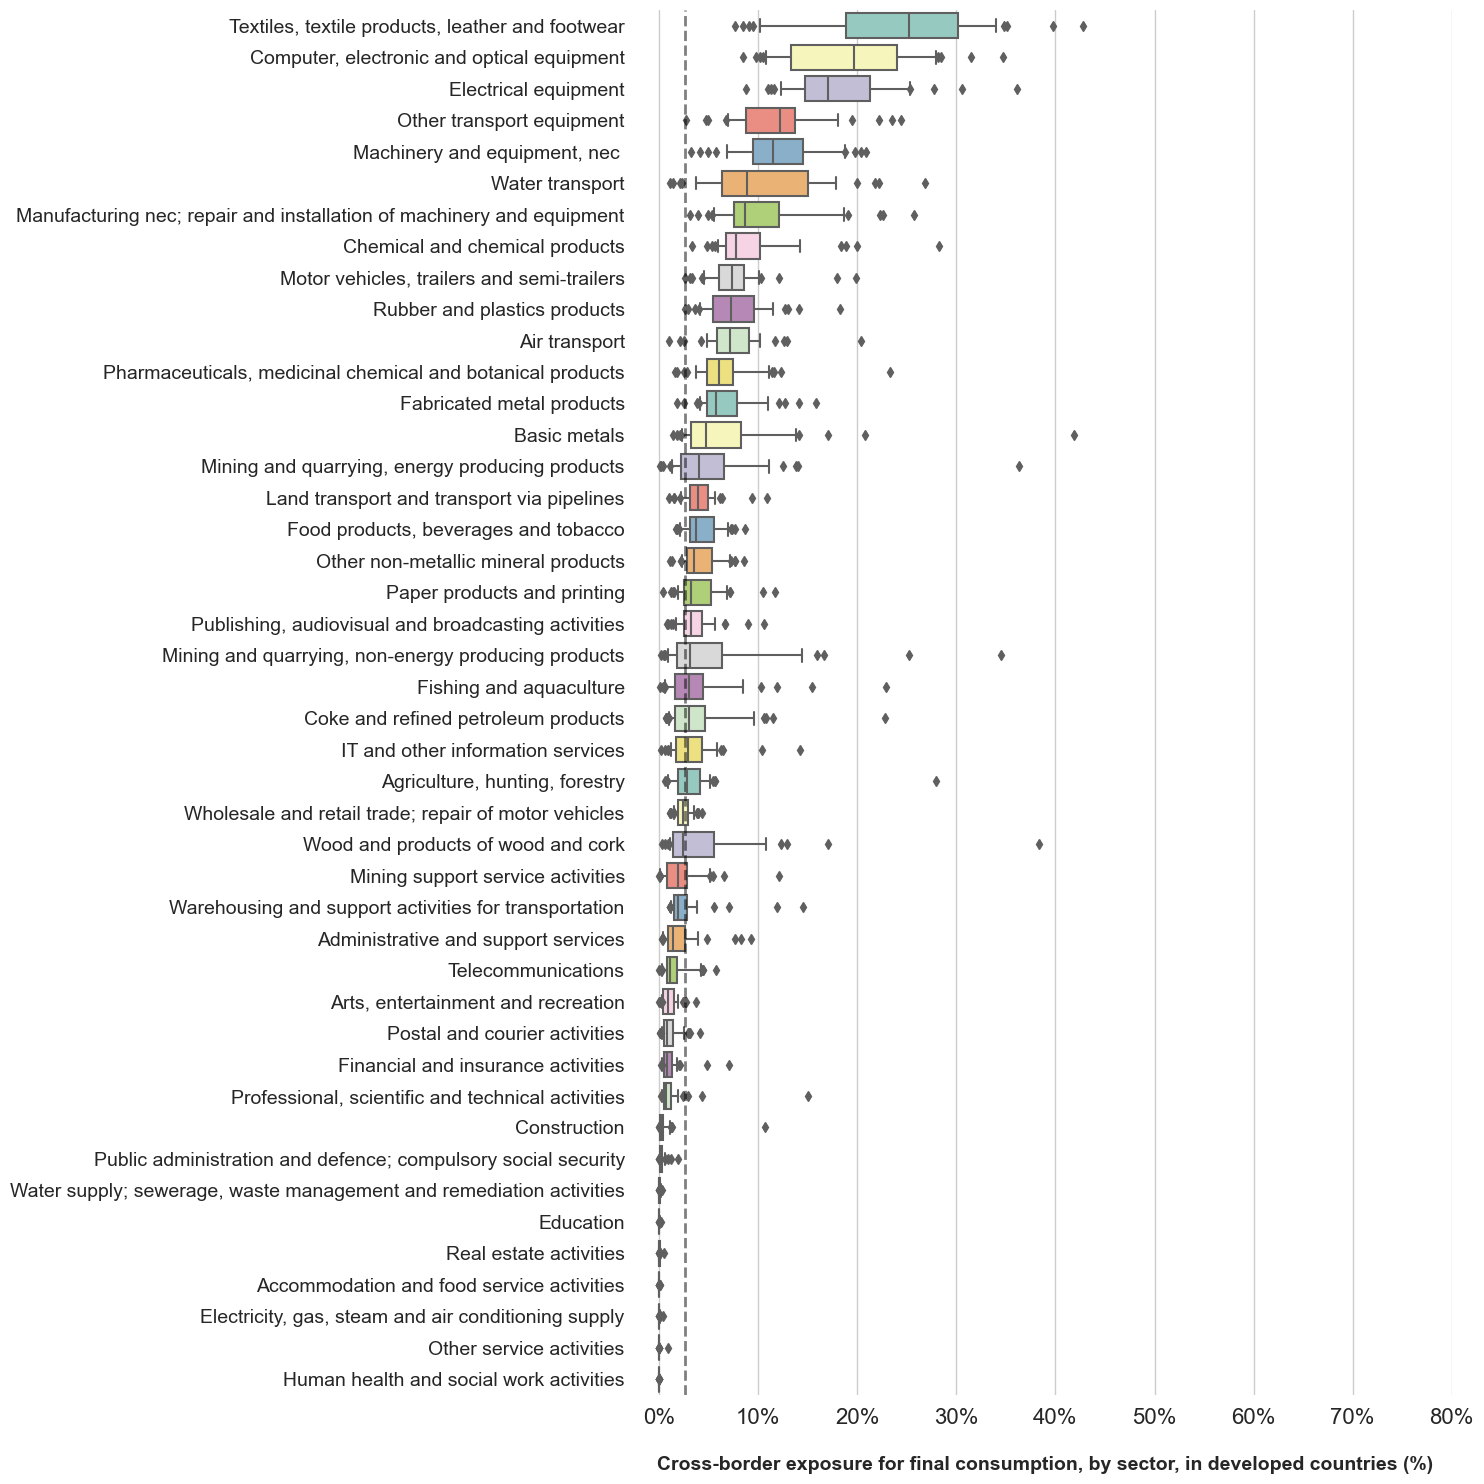

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming your dataframe is loaded as df
df = resulting_dataframe_sectors_cons_leontief

# Split the data
df_developed = df[df['Development'] == 'Developed']

# Calculate the IQR and determine outliers manually
Q1 = df_developed['High Risk Exposure (%)'].quantile(0.25)
Q3 = df_developed['High Risk Exposure (%)'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_developed[(df_developed['High Risk Exposure (%)'] < (Q1 - 1.5 * IQR)) | (df_developed['High Risk Exposure (%)'] > (Q3 + 1.5 * IQR))]

print("Number of outliers:", len(outliers))
print("Outlier values:", outliers['High Risk Exposure (%)'].tolist())

# Calculate the median 'High Risk Exposure (%)' for each sector in developed countries
sector_medians_developed = df_developed.groupby('sector')['High Risk Exposure (%)'].median()
sector_medians_developed = sector_medians_developed.sort_values(ascending=False)

# Set the threshold for median
threshold = 0  # Adjust this threshold as needed

# Filter sectors based on the threshold
selected_sectors = sector_medians_developed[sector_medians_developed > threshold].index
# Sort the sectors by these medians in descending order
sorted_sectors = sector_medians_developed.sort_values(ascending=False).index

# Set the style for the plots
sns.set(style="whitegrid")

# Create a figure and axes
fig, ax = plt.subplots(figsize=(15, 15))

# Create the boxplot with horizontal orientation for selected sectors
sns.boxplot(y='sector', x='High Risk Exposure (%)', data=df_developed[df_developed['sector'].isin(selected_sectors)], ax=ax,
            order=selected_sectors, orient='h', palette="Set3",whis=[10, 90])


# Annotations and aesthetics
ax.axvline(x=median_high_risk_developed_consumption, color='black', linestyle='--', linewidth=2, alpha=0.5)

# Suppress the y-axis label
ax.set_ylabel('')

# Suppress the frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Customize x-axis
x_ticks = np.linspace(0, 80, 9)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f'{x:.0f}%' for x in x_ticks], fontsize=16)

# Customize y-axis
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)

# Set x-axis label
ax.set_xlabel('Cross-border exposure for final consumption, by sector, in developed countries (%)', fontsize=14, fontweight='bold', labelpad=20)

plt.tight_layout()
plt.savefig(r"Figures\Supp Mat\D\Fig1a.png")
plt.show()

## Exports

### Code

In [18]:
import pandas as pd    

Y= mriot.Y.copy()
x= mriot.x
y= Y.sum(axis = 1)
y= y.apply(lambda y: max(y, 0))

L= mriot.L

country_list = L.index.get_level_values(0).unique()
sector_list = L.index.get_level_values(1).unique()

index_cs = mriot.x.index

values = {'Low Risk': [0] * index_cs.size}
Foreign_Exports_low = pd.DataFrame(values, index=index_cs)

values = {'High Risk': [0] * index_cs.size}
Foreign_Exports_high = pd.DataFrame(values, index=index_cs)

values = {'ROW': [0] * index_cs.size}
Foreign_Exports_ROW = pd.DataFrame(values, index=index_cs)

values = {'Local (%)': [0] * index_cs.size}
Local_Exports = pd.DataFrame(values, index=index_cs)

values = {'Foreign (%)': [0] * index_cs.size}
Foreign_Exports = pd.DataFrame(values, index=index_cs)

for c in country_list:
    y_except_c = y[~y.index.get_level_values('region').isin([c])]
    y_except_c_low = y_except_c[y_except_c.index.get_level_values('region').isin(low_risk_countries)]
    y_except_c_high = y_except_c[y_except_c.index.get_level_values('region').isin(high_risk_countries)]
    y_except_c_row = y_except_c[y_except_c.index.get_level_values('region').isin(no_risk_countries)]

    for s in sector_list:
        L_cs = L.loc[c,s]
        x_cs = (L_cs*y).sum()
        
        L_cs = L_cs[L_cs.index.get_level_values('region') != c]
        L_cs_foreign_low = L_cs[L_cs.index.get_level_values('region').isin(low_risk_countries)]
        L_cs_foreign_high = L_cs[L_cs.index.get_level_values('region').isin(high_risk_countries)]
        L_cs_foreign_row = L_cs[L_cs.index.get_level_values('region').isin(no_risk_countries)]

        exports_cs = (L_cs*y_except_c).sum()
                    
        exports_cs_low = (L_cs_foreign_low*y_except_c_low).sum()
        exports_cs_high = (L_cs_foreign_high*y_except_c_high).sum()
        exports_cs_row = (L_cs_foreign_row*y_except_c_row).sum()

        Foreign_Exports.loc[c,s] = exports_cs / x_cs*100
        Foreign_Exports_low.loc[c,s] = exports_cs_low / x_cs*100
        Foreign_Exports_high.loc[c,s] = exports_cs_high / x_cs *100
        Foreign_Exports_ROW.loc[c,s] = exports_cs_row / x_cs *100
        Local_Exports.loc[c,s] = 100 - Foreign_Exports.loc[c,s].iloc[0]
            
# List of DataFrames to concatenate
dataframes_to_concat = [Foreign_Exports_low, Foreign_Exports_high,Foreign_Exports_ROW, Foreign_Exports,Local_Exports]

# Concatenate the DataFrames along columns (axis=1)
resulting_dataframe_sectors_exports_leontief_CI = pd.concat(dataframes_to_concat, axis=1)

# Sorting the data by 'Non-OECD' for better visualization
result = resulting_dataframe_sectors_exports_leontief_CI.sort_values('Foreign (%)', ascending=False).reset_index()

# Define the function to categorize development status
def categorize_local_risk(region):
    if region in low_risk_countries:
        return 'Low Risk'
    elif region in high_risk_countries:
        return 'High Risk'
    else:
        return 'Unknown'
    
result['Local Risk'] = result['region'].apply(categorize_local_risk)

# Merge the two DataFrames on 'region' column
result = result.merge(local_climate_risk, left_on='region', right_on='Country Code', how='left')

path='Other_data/World_Bank_Regions.xlsx'
wb_regions = pd.read_excel(path)
result = result.merge(wb_regions, left_on='Country Code', right_on='Code', how='left')

path='Other_data/World_Bank_Pop.csv'
wb_pop = pd.read_csv(path, delimiter=';')  # If semicolon-separated
result = result.merge(wb_pop, left_on='Country Code', right_on='Country Code', how='left')

result = result.drop(columns=['Series Name','Series Code','region','Country Name','Lending category','Economy','Code'])
result.rename(columns={'2023 [YR2023]':'Population'},inplace=True)

# Convert the column to numeric
result['Population'] = pd.to_numeric(result['Population'], errors='coerce').fillna(0)

# Define the function to categorize development status
def categorize_development(region):
    if region in least_developed_countries:
        return 'Least Developed'
    elif region in developed_countries:
        return 'Developed'
    elif region in developing_countries:
        return 'Developing'
    else:
        return 'Unknown'

result['Development'] = result['Country'].apply(categorize_development)

result['Share of Risky Trade Partners (%)']=result['High Risk']/(result['High Risk']+result['Low Risk'])*100
result = result.rename(columns={'High Risk': 'High Risk Exposure (%)'})
result = result.rename(columns={'Low Risk': 'Low Risk Exposure (%)'})

result = result[['Country','Country Code','Local Climate Risk','Local Risk','Region','Income group','Population','Development','sector', 'Low Risk Exposure (%)', 'High Risk Exposure (%)','ROW','Foreign (%)','Local (%)',  'Share of Risky Trade Partners (%)']]

# Data are added manually for South and North Sudan because of uncorresponding country codes

result.loc[result['Country'] == 'South Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'South Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'South Sudan', 'Population'] = 11088796

result.loc[result['Country'] == 'Sudan', 'Region'] = 'Sub-Saharan Africa'
result.loc[result['Country'] == 'Sudan', 'Income group'] = 'Low income'
result.loc[result['Country'] == 'Sudan', 'Population'] = 48109006

result=result.reset_index()
result = result.drop('index', axis=1)

result = result.dropna(subset=['Region'])

resulting_dataframe_sectors_exports_leontief_CI=result

C:\Users\delah\AppData\Local\Temp\ipykernel_16884\3606477600.py:51: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '14.284431869976219' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Foreign_Exports.loc[c,s] = exports_cs / x_cs*100
C:\Users\delah\AppData\Local\Temp\ipykernel_16884\3606477600.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '4.877581224666781' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Foreign_Exports_low.loc[c,s] = exports_cs_low / x_cs*100
C:\Users\delah\AppData\Local\Temp\ipykernel_16884\3606477600.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '7.813929043377936' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Foreign_Exp

### Plot

C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\delah\anaconda3\envs\Boario\lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


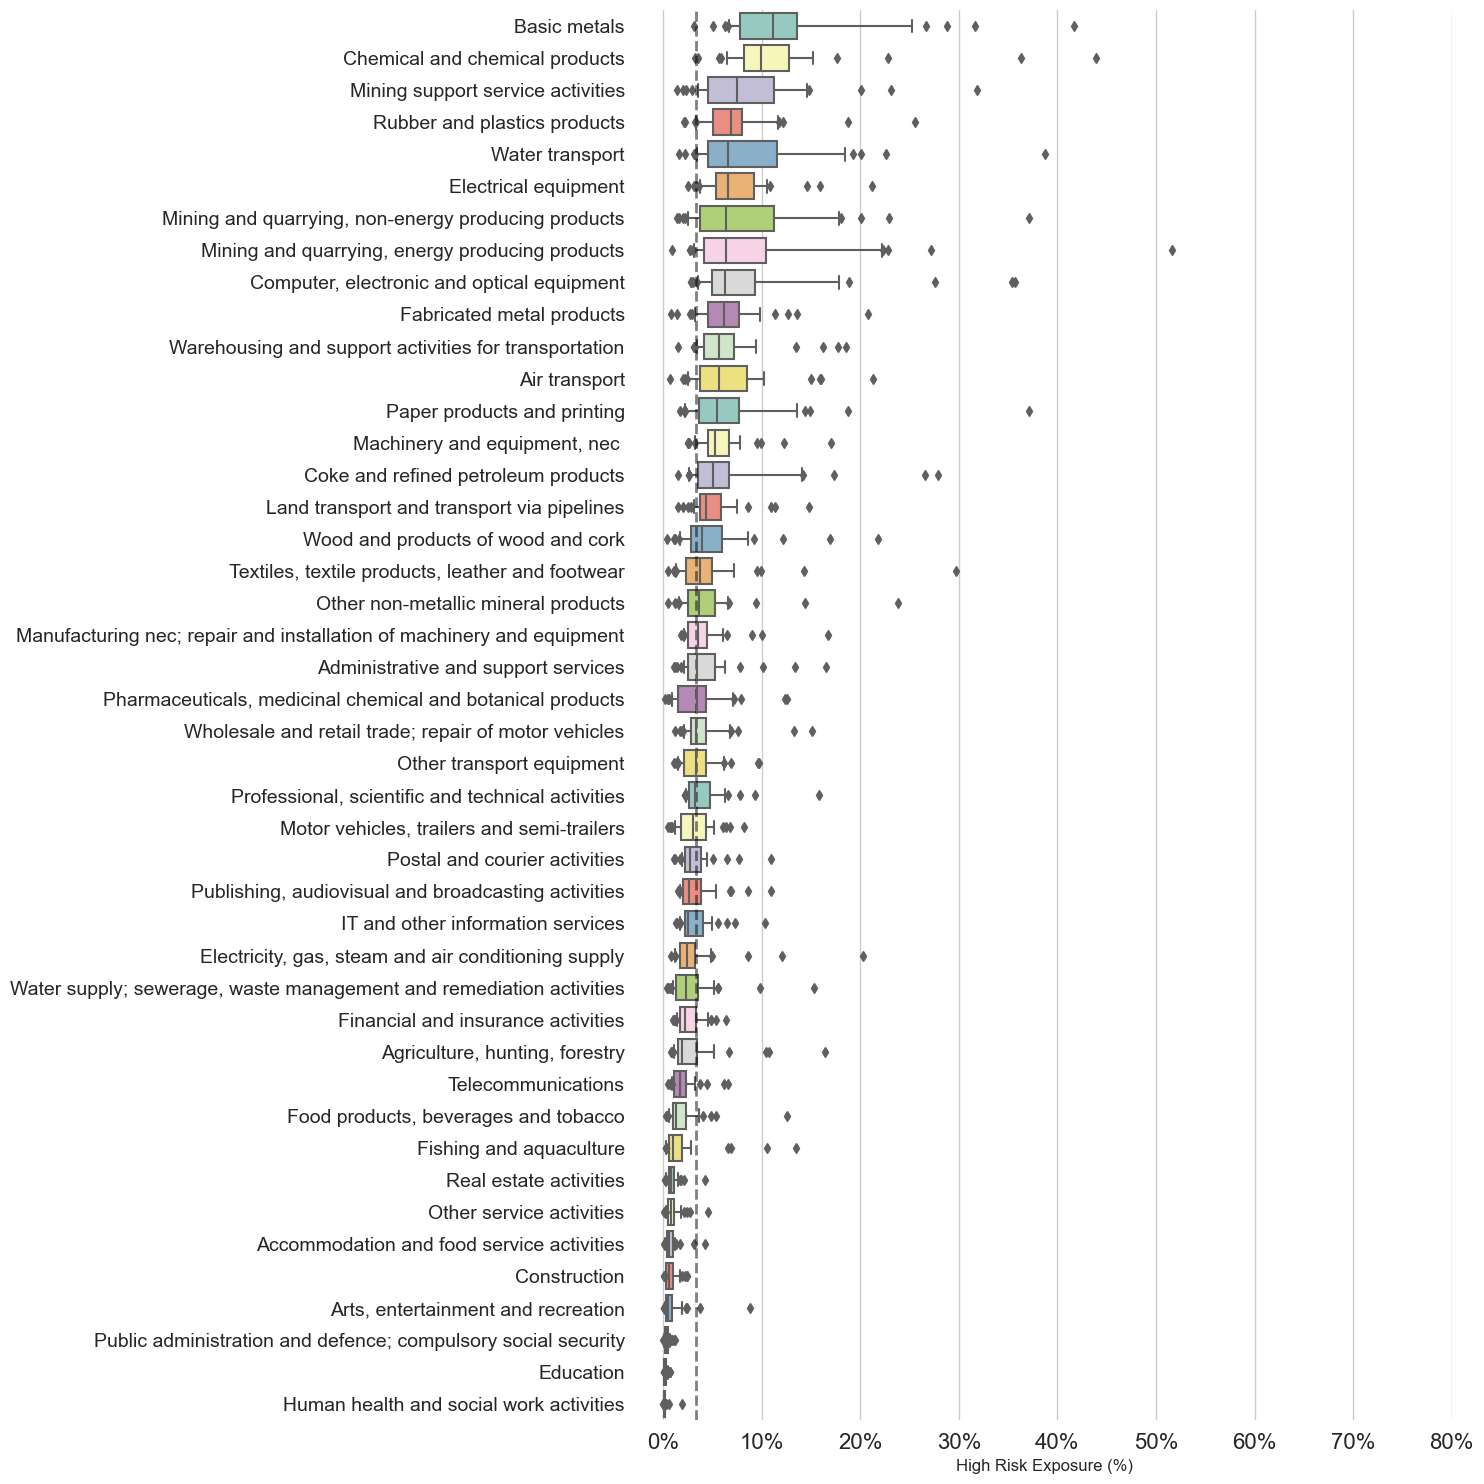

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming your dataframe is loaded as df
df = resulting_dataframe_sectors_exports_leontief_CI
# Split the data
df_developed = df[df['Development'] == 'Developed']

# Calculate the IQR and determine outliers manually
Q1 = df_developed['High Risk Exposure (%)'].quantile(0.25)
Q3 = df_developed['High Risk Exposure (%)'].quantile(0.75)
IQR = Q3 - Q1

# Calculate the median 'High Risk' for each sector in developed countries
sector_medians_developed = df_developed.groupby('sector')['High Risk Exposure (%)'].median()
sector_medians_developed = sector_medians_developed.sort_values(ascending=False)

# Set the threshold for median
threshold = 0  # Adjust this threshold as needed

# Filter sectors based on the threshold
selected_sectors = sector_medians_developed[sector_medians_developed > threshold].index
# Sort the sectors by these medians in descending order
sorted_sectors = sector_medians_developed.sort_values(ascending=False).index

# Set the style for the plots
sns.set(style="whitegrid")

# Create a figure and axes
fig, ax = plt.subplots(figsize=(15, 15))

# Create the boxplot with horizontal orientation for selected sectors
sns.boxplot(y='sector', x='High Risk Exposure (%)', data=df_developed[df_developed['sector'].isin(selected_sectors)], ax=ax,
            order=selected_sectors, orient='h', palette="Set3",whis=[10, 90])


# Annotations and aesthetics
ax.axvline(x=median_high_risk_developed_exports_inputs, color='black', linestyle='--', linewidth=2, alpha=0.5)

# Suppress the y-axis label
ax.set_ylabel('')

# Suppress the frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)

# Customize x-axis
x_ticks = np.linspace(0, 80, 9)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f'{x:.0f}%' for x in x_ticks], fontsize=16)

# Customize y-axis
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)

# Set x-axis label
#ax.set_xlabel('Cross-border exposure for exports of intermediates, by product, in developed countries (%)', fontsize=14, fontweight='bold', labelpad=20)

plt.tight_layout()
plt.show()

## Concentration

### Code

Computing Hirschman-Herfindahl Index on the share of imported goods coming from each country

HHI = 1 when there is only one supplier. When an infinity of suppliers, HHI = 0.

In [58]:
multi_index = pd.MultiIndex.from_product([country_list, sector_list], names=['country', 'sector'])

values = {'HHI': [0] * multi_index.size}
hhi_inputs = pd.DataFrame(values, index=multi_index)

L=mriot.L
y= Y.sum(axis = 1)

for c in country_list:
    for s in sector_list:
        L_c=L[c]
        y_c=y[c]
        L_c=L_c.loc[~L.index.get_level_values('region').isin([c])]
        total_inputs_ext_s_to_c = L_c.groupby('sector').sum().loc[s].dot(y_c)
        hhi=0
        if total_inputs_ext_s_to_c>0:
            hhi=0
            country_list_except_c = [item for item in country_list if item != c]
            for c0 in country_list_except_c:
                share_c0 = L_c.loc[c0,s].dot(y_c)/total_inputs_ext_s_to_c
                hhi = hhi + share_c0**2
        hhi_inputs.loc[c,s]=hhi

C:\Users\delah\AppData\Local\Temp\ipykernel_16120\41654026.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.23213742441131155' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  hhi_inputs.loc[c,s]=hhi


In [60]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/hhi_inputs_icio_inform.pkl'

# Save the dictionary to a file
#with open(file_path_pickle, 'wb') as f:
    pickle.dump(hhi_inputs, f)

In [29]:
import pickle

# Explicit file path
file_path_pickle = 'INFORM_Climate_Change/results/hhi_inputs_icio_inform.pkl'

# Load the dictionary from the file
with open(file_path_pickle, 'rb') as f:
    hhi_inputs = pickle.load(f)

Final Consumption

In [30]:
multi_index = pd.MultiIndex.from_product([country_list, sector_list], names=['country', 'sector'])

values = {'HHI': [0] * multi_index.size}
hhi_cons = pd.DataFrame(values, index=multi_index)

L=mriot.L
y= Y.sum(axis = 1)

Y = mriot.Y.copy()
idx = pd.IndexSlice
# List of categories you want to keep
categories_to_keep = [
    'HFCE'
]


# Filtering to get only columns where the second level matches the categories listed
Y = Y.loc[:, idx[:, categories_to_keep]]

Y = Y.groupby(level='region', axis=1).sum()

for c in country_list:
    for s in sector_list:
        Y_c =Y[c]
        total_cons_ext_s_to_c = Y_c.loc[~Y_c.index.get_level_values('region').isin([c])].groupby('sector').sum().loc[s]
        hhi=0
        if total_cons_ext_s_to_c>0:
            country_list_except_c = [item for item in country_list if item != c]
            for c0 in country_list_except_c:
                share_c0 = Y_c.loc[c0,s]/total_cons_ext_s_to_c
                hhi = hhi + share_c0**2
        hhi_cons.loc[c,s]=hhi

C:\Users\delah\AppData\Local\Temp\ipykernel_16556\3523557857.py:20: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  Y = Y.groupby(level='region', axis=1).sum()
C:\Users\delah\AppData\Local\Temp\ipykernel_16556\3523557857.py:32: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0.5941996782159663' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  hhi_cons.loc[c,s]=hhi


### Plot

In [37]:
df1=resulting_dataframe_sectors_cons_leontief
df2=hhi_cons
result = pd.merge(df1, df2, left_on=['Country Code', 'sector'], right_on=['country', 'sector'], how='left')
df=result

In [35]:
df1=resulting_dataframe_sectors_inputs_leontief
df2=hhi_inputs
result = pd.merge(df1, df2, left_on=['Country Code', 'sector'], right_on=['country', 'sector'], how='left')
df=result

C:\Users\delah\AppData\Local\Temp\ipykernel_16556\3085801839.py:42: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.annotate(txt, (filtered_sector_medians['High Risk Exposure (%)'][i], filtered_sector_medians['HHI'][i]),fontsize=12)


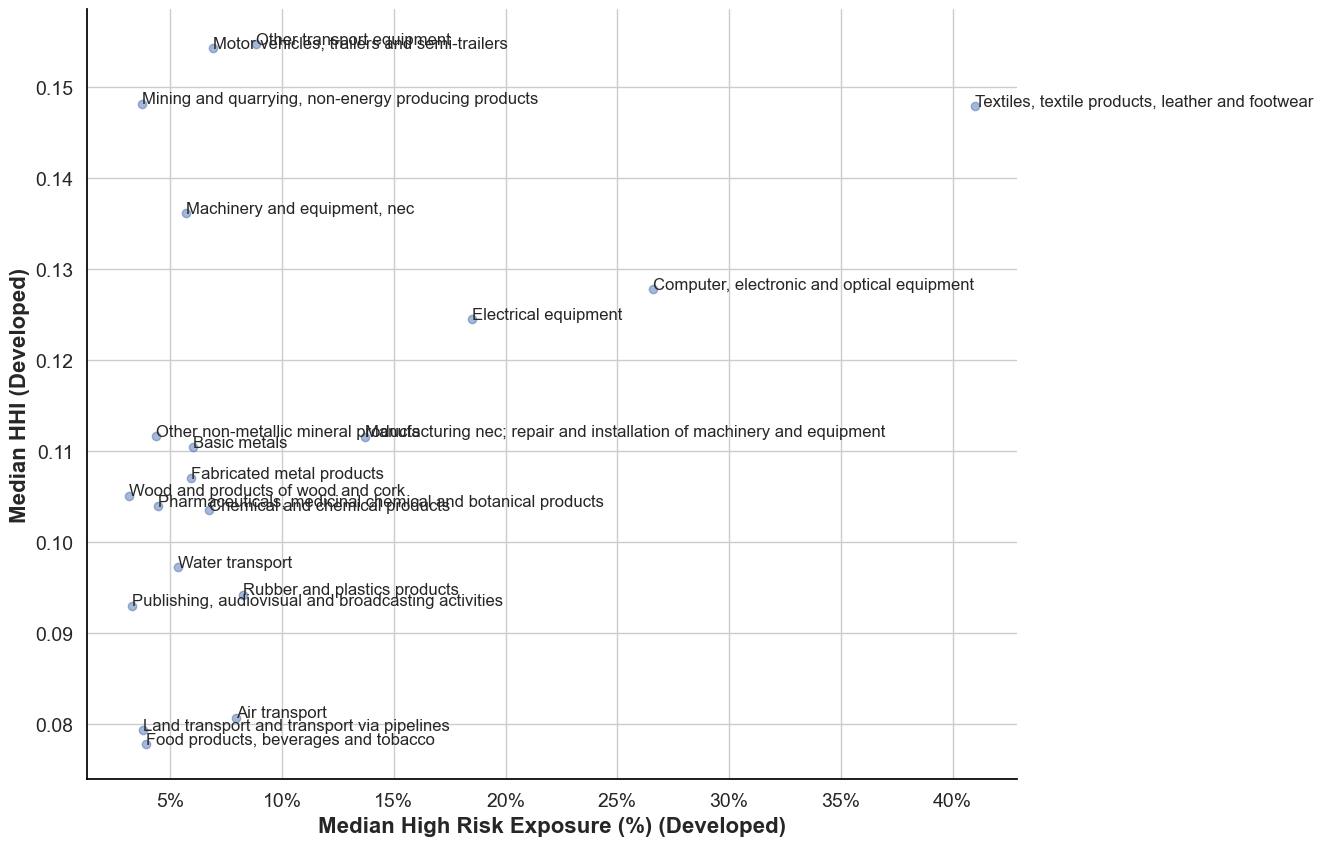

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming your data is already in a DataFrame named 'df'
# Filter the DataFrame to only include rows where Development is 'Developed'
developed_df = df[df['Development'] == 'Developed']

# Group by 'sector' and calculate median values specifically for numeric columns
sector_medians = developed_df.groupby('sector').median(numeric_only=True)[['High Risk Exposure (%)', 'HHI']]

# Filter out sectors where the median High Risk Exposure (%) is less than 2%
filtered_sector_medians = sector_medians[sector_medians['High Risk Exposure (%)'] >= median_high_risk_developed_consumption]
#filtered_sector_medians = sector_medians[sector_medians['High Risk Exposure (%)'] >= median_high_risk_developed_inputs]

# Plotting
plt.figure(figsize=(12, 10))
ax = plt.gca()  # Get current axis

# Removing top and right borders and setting the bottom and left spines black
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

# Scatter plot without the incorrect 'fontsize' parameter
plt.scatter(filtered_sector_medians['High Risk Exposure (%)'], filtered_sector_medians['HHI'], alpha=0.5)

# Setting labels with font size and weight adjustments
plt.xlabel('Median High Risk Exposure (%) (Developed)', fontsize=16, fontweight='bold')
plt.ylabel('Median HHI (Developed)', fontsize=16, fontweight='bold')

# Formatting the x-axis labels as percentages and setting label sizes
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# Setting grid
plt.grid(True)

# Adding sector labels to the points
for i, txt in enumerate(filtered_sector_medians.index):
    plt.annotate(txt, (filtered_sector_medians['High Risk Exposure (%)'][i], filtered_sector_medians['HHI'][i]),fontsize=12)

    
plt.savefig(r"Figures\Supp Mat\D\Fig3a.png") # Cons
#plt.savefig(r"Figures\Supp Mat\D\Fig3c.png") # Inputs


plt.show()